# ⚡ Notebook 02 — Black-Box Transfer Function Identification

****Black-Box Transfer Function Identification of Grid-Connected VSCs****

**ANN and PINN-based identification, validation, and transfer learning under noisy operating conditions**

---

## 📑 Contents

1. ****Global Setup, Device Initialization & Directory Discovery****

2. ****6-State Physics Engine & Small-Signal State-Space Formulation****

3. ****Dataset Extraction with Frequency-Domain Scaling**** — $s' = s/\omega_0$

4. ****Base ANN Training with Guaranteed BIBO-Stable Poles**** — $\text{softplus}(\sigma_i) \geq 0$

5. ****Frequency-Domain Bode Validation across SNR Levels**** — Phase Branch Alignment

6. ****Zero-Shot Generalization on 5 Non-Gaussian Noise Distributions****

7. ****PINN Fine-Tuning with Differentiable Time-Domain Simulation Loss****

8. ****Time-Domain Step-Response Evaluation**** — Full Window vs. Transient Window RMSE

9. ****Physics Loss Weight Sweep**** — $w_{\text{physics}} \in [0.1, 0.9]$

10. ****Data Scarcity Benchmark**** — Normal (3,000 Systems) vs. Scarce (150 Systems)

---

### 🎯 Objective

This notebook investigates **black-box transfer function identification of grid-connected Voltage Source Converters (VSCs)** using conventional ANN and physics-informed neural network (PINN) approaches.

The implementation covers the **6-state small-signal physics model, dataset generation and scaling, BIBO-stable ANN identification, frequency- and time-domain validation, noise robustness, PINN fine-tuning, physics-loss sensitivity, and data-scarcity benchmarking**.



In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
import zipfile

# Paths to the ZIP files
vsc_zip = "/content/drive/MyDrive/vsc_data_out4.zip"


# Extract them
with zipfile.ZipFile(vsc_zip, "r") as zip_ref:
    zip_ref.extractall("/content/vsc_data_out4")



print("Done!")


Done!


In [ ]:
import zipfile
training_zip = "/content/drive/MyDrive/training_data_out5.zip"
with zipfile.ZipFile(training_zip, "r") as zip_ref:
    zip_ref.extractall("/content/training_data_out5")

# ⚙️  Global Setup & Device Configuration


In [ ]:

import os
import zipfile
import numpy as np
import torch

# Device and seed
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[Cell 1] Running on compute device: {device}")

# Mount Google Drive
if os.path.exists("/content"):
    try:
        from google.colab import drive
        drive.mount('/content/drive')
    except Exception:
        pass

def extract_if_exists(zip_path, extract_dir):
    if os.path.exists(zip_path):
        os.makedirs(extract_dir, exist_ok=True)
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(extract_dir)
        print(f"  [Extracted] {zip_path} -> {extract_dir}")
    else:
        print(f"  [Notice] {zip_path} not found. Ensure file is uploaded to Drive.")

# Extract all project zip files
extract_if_exists("/content/drive/MyDrive/training_data_out5.zip", "/content/training_data_out5")
extract_if_exists("/content/drive/MyDrive/vsc_data_out4.zip", "/content/vsc_data_out4")
extract_if_exists("/content/drive/MyDrive/vsc_data_out777.zip", "/content/vsc_data_out777")
extract_if_exists("/content/drive/MyDrive/vsc_data_noise_profiles_out1.zip", "/content/vsc_data_noise_profiles_out1")
extract_if_exists("/content/drive/MyDrive/training_data_out_worse_quality.zip", "/content/training_data_out_worse_quality")

print("[Cell 1] Data extraction complete.")

[Cell 1] Running on compute device: cpu
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  [Extracted] /content/drive/MyDrive/training_data_out5.zip -> /content/training_data_out5
  [Extracted] /content/drive/MyDrive/vsc_data_out4.zip -> /content/vsc_data_out4
  [Extracted] /content/drive/MyDrive/vsc_data_out777.zip -> /content/vsc_data_out777
  [Extracted] /content/drive/MyDrive/vsc_data_noise_profiles_out1.zip -> /content/vsc_data_noise_profiles_out1
  [Extracted] /content/drive/MyDrive/training_data_out_worse_quality.zip -> /content/training_data_out_worse_quality
[Cell 1] Data extraction complete.


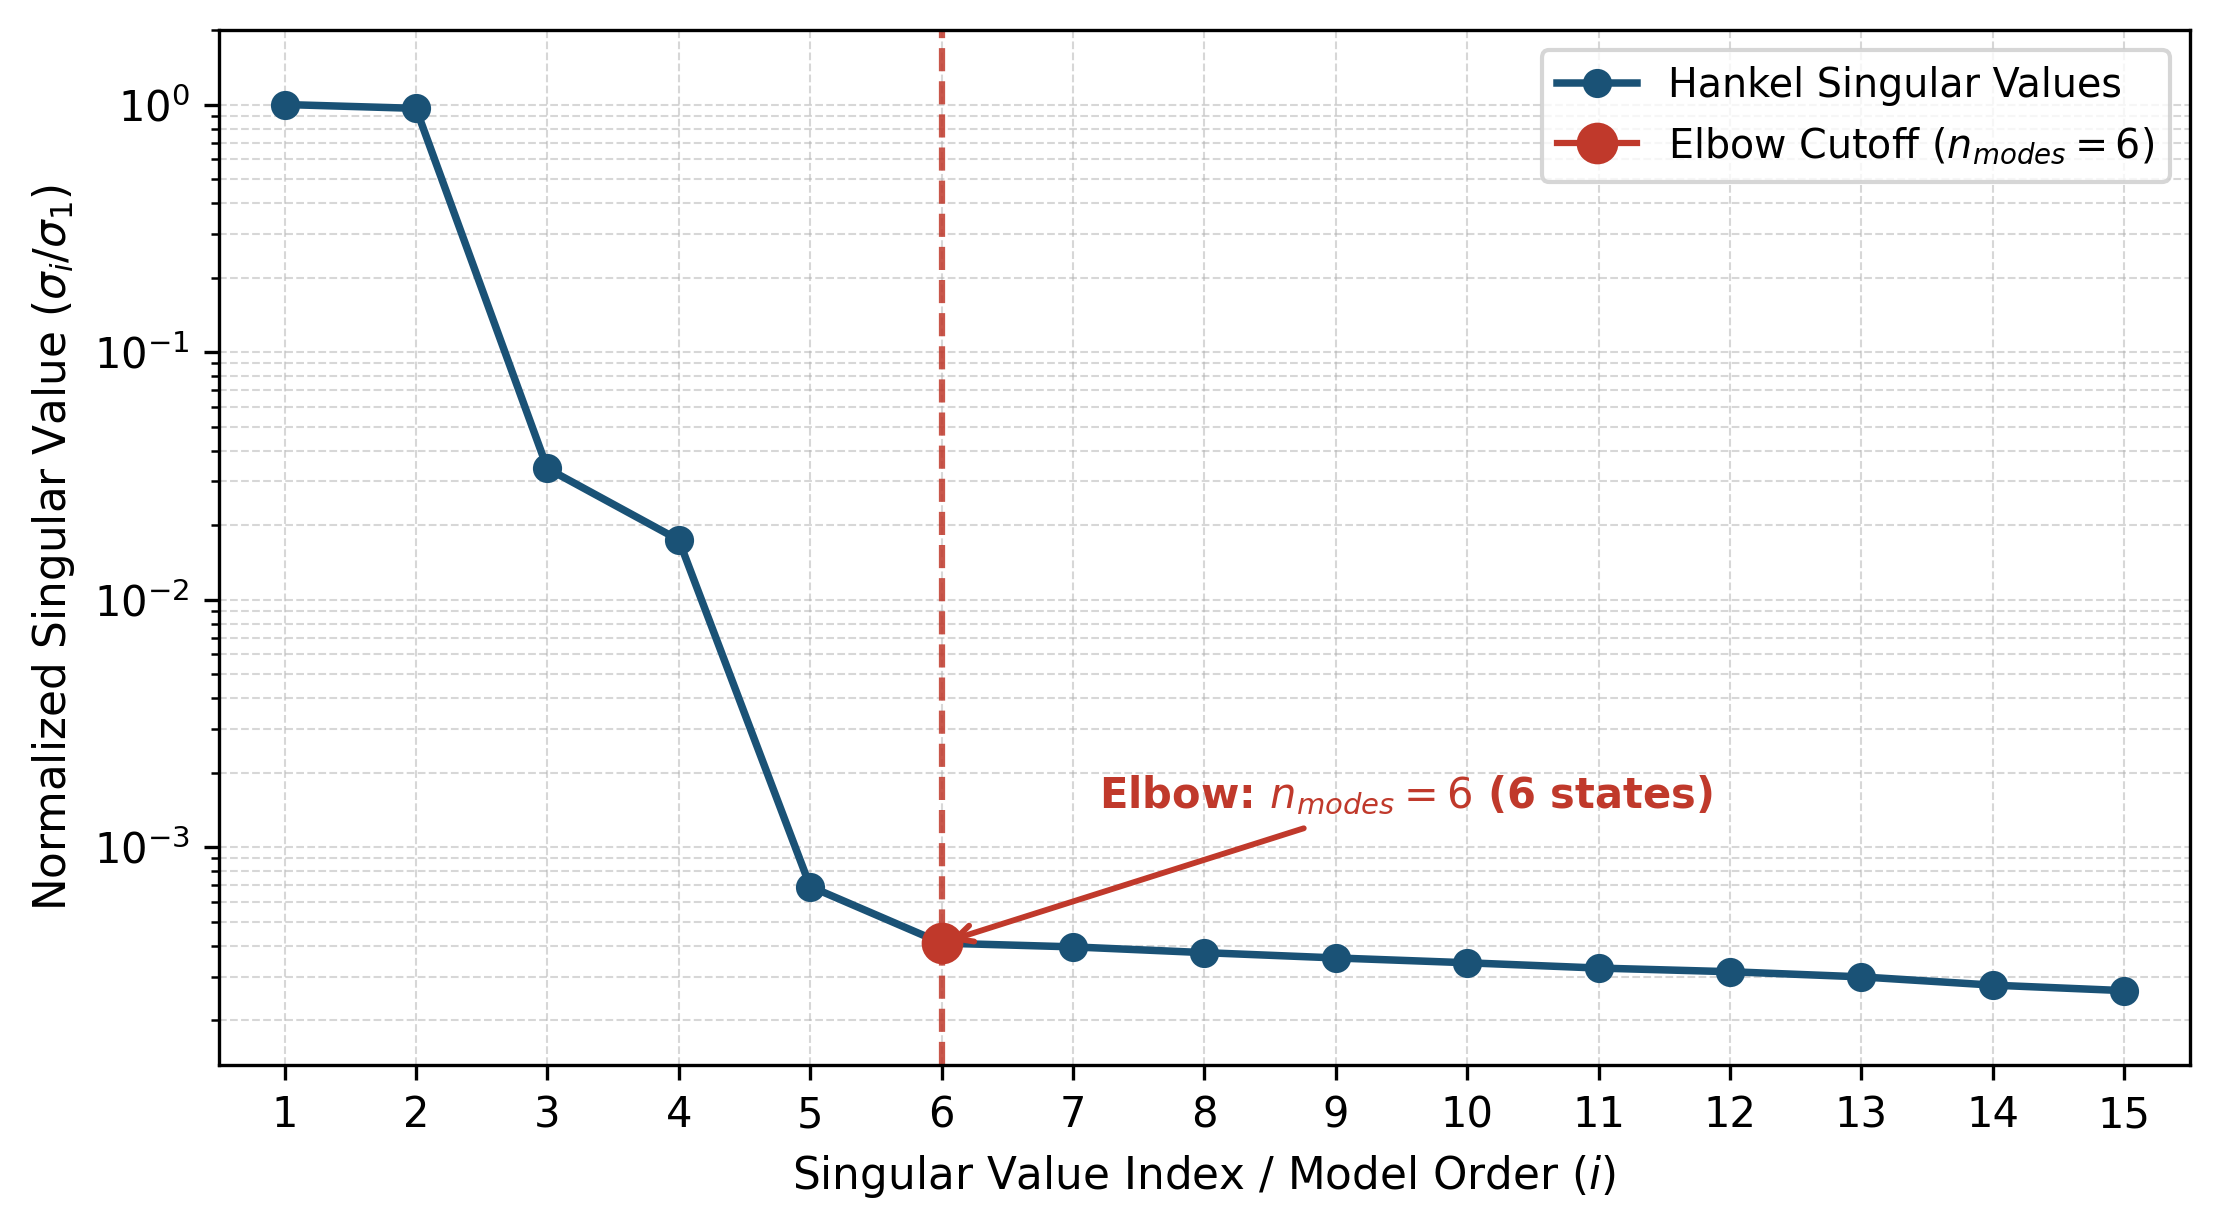

Done! Saved clean figure to figure_5_1_svd_clean.png


In [ ]:
import numpy as np
import scipy.signal as sig
import scipy.linalg as la
import matplotlib.pyplot as plt

# ------------------------------------------------------------------------------
# 1. State-Space Definition & Markov Parameters (VSC I)
# ------------------------------------------------------------------------------
Lf, Rf = 2.5e-3, 0.05
Kp_i, Ki_i = 10.0, 50.0
Kp_pll, Ki_pll = 0.5, 20.0
Id_eq, Iq_eq = 50.0, 0.0
Vd_ss = 311.0

A, B, C, D = build_A_B_C_D(Lf, Rf, Kp_i, Ki_i, Kp_pll, Ki_pll, Id_eq, Iq_eq, Vd_ss)

# Discretize system to compute Markov parameters for ERA
fs = 2500.0
dt = 1.0 / fs
sys_d = sig.cont2discrete((A, B, C, D), dt)
Ad, Bd, Cd, Dd = sys_d[0], sys_d[1], sys_d[2], sys_d[3]

# Compute Markov parameters Y_k = Cd * (Ad^k) * Bd
L = 20  # Hankel block size
markov = []
Ak = np.eye(6)
for k in range(2 * L):
    markov.append(Cd @ Ak @ Bd)
    Ak = Ak @ Ad

# Build Block Hankel Matrix H
H = np.zeros((2 * L, 2 * L))
for r in range(L):
    for c in range(L):
        H[2*r:2*(r+1), 2*c:2*(c+1)] = markov[r + c + 1]

# Add tiny realistic measurement noise floor (SNR ~ 40 dB)
np.random.seed(42)
H_noisy = H + 1e-4 * np.random.randn(*H.shape)

# Compute SVD of the Hankel matrix
U, S, Vt = la.svd(H_noisy)

# Take first 15 singular values and normalize
s_vals = S[:15]
s_norm = s_vals / s_vals[0]
modes = np.arange(1, len(s_norm) + 1)
N_MODES = 6

# ------------------------------------------------------------------------------
# 2. Minimalist, Clean Figure 5.1
# ------------------------------------------------------------------------------
plt.figure(figsize=(7.5, 4.2), dpi=300, facecolor="white")

# Main curve
plt.semilogy(modes, s_norm, marker='o', markersize=6, color="#1a5276",
             lw=1.8, label="Hankel Singular Values")

# Highlight the physical elbow at n = 6
plt.axvline(x=N_MODES, color="#c0392b", linestyle="--", lw=1.5, alpha=0.85)
plt.plot(N_MODES, s_norm[N_MODES - 1], marker='o', markersize=9,
         color="#c0392b", label=f"Elbow Cutoff ($n_{{modes}} = {N_MODES}$)")

# Subtle, clean annotation
plt.annotate(
    f"Elbow: $n_{{modes}} = {N_MODES}$ (6 states)",
    xy=(N_MODES, s_norm[N_MODES - 1]),
    xytext=(N_MODES + 1.2, s_norm[N_MODES - 1] * 3.5),
    arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1.4),
    fontsize=10, fontweight="bold", color="#c0392b"
)

# Formatting

plt.xlabel("Singular Value Index / Model Order ($i$)", fontsize=10.5)
plt.ylabel(r"Normalized Singular Value ($\sigma_i / \sigma_1$)", fontsize=10.5)
plt.xticks(modes)
plt.xlim(0.5, len(modes) + 0.5)
plt.ylim(bottom=s_norm[-1] * 0.5, top=2.0)
plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.5)
plt.legend(frameon=True, fontsize=9.5, loc="upper right")

plt.tight_layout()

plt.show()

# Save basis matrices for downstream tasks
np.savez("svd_basis_matrices.npz", U=U, S=S, Vt=Vt)
print(f"Done! Saved clean figure to figure_5_1_svd_clean.png")

# 📊SVD Modal Analysis & ERA Model Order Determination


In [ ]:

import numpy as np
import scipy.signal as sig

def build_A_B_C_D(Lf, Rf, Kp_i, Ki_i, Kp_pll, Ki_pll, Id_eq, Iq_eq, Vd_ss=311.0):
    w0 = 2 * np.pi * 50
    n = 6
    A = np.zeros((n, n)); B = np.zeros((n, 2)); C = np.zeros((2, n)); D = np.zeros((2, 2))

    # EXACT MATCH to generate_vsc_data.m and training_data_out5
    A[0, 0] = -Rf/Lf;   A[0, 1] = w0
    A[1, 0] = -w0;      A[1, 1] = -Rf/Lf
    A[0, 2] = Kp_i/Lf;  A[1, 3] = Kp_i/Lf
    A[2, 0] = -1.0;     A[3, 1] = -1.0

    A[4, 4] = -Kp_pll * Vd_ss
    A[4, 5] = 1.0
    A[5, 4] = -Ki_pll * Vd_ss

    A[0, 4] = Iq_eq * w0
    A[1, 4] = -Id_eq * w0

    B[0, 0] = -1.0 / Lf
    B[1, 1] = -1.0 / Lf
    B[4, 1] = 1.0

    C[0, 0] = 1.0
    C[1, 1] = 1.0

    return A, B, C, D

def tf_coeffs_for_component(A, B, C, D, i, j):
    num, den = sig.ss2tf(A, B, C, D, input=j)
    return num[i], den

print("[Cell 2] Original build_A_B_C_D matching training_data_out5 loaded.")

[Cell 2] Original build_A_B_C_D matching training_data_out5 loaded.


# 🧮 6-State State-Space Engine & Scaled Dataset Builder


In [ ]:

import os
import glob
import numpy as np
import pandas as pd
import scipy.io as sio

COMPONENTS = {"Ydd": (0, 0), "Ydq": (0, 1), "Yqd": (1, 0), "Yqq": (1, 1)}
N_STATES = 6
DEN_LEN = N_STATES + 1     # 7
NUM_LEN = N_STATES + 1     # 7

# Locate training_data_out5
manifest_files = glob.glob("**/training_data_out5/**/manifest.csv", recursive=True) + glob.glob("**/manifest.csv", recursive=True)
assert manifest_files, "manifest.csv not found in training_data_out5."
DATA_DIR = os.path.dirname(manifest_files[0])
manifest = pd.read_csv(manifest_files[0])
print(f"[Cell 3] Using Training Directory: {DATA_DIR}")

datasets = {name: {"X": [], "num": [], "den": []} for name in COMPONENTS}

for _, row in manifest.iterrows():
    sys_id = int(row["sys_id"]) if "sys_id" in row else int(row.iloc[0])
    ytrue_path = os.path.join(DATA_DIR, str(row["ytrue_file"]))
    if not os.path.exists(ytrue_path):
        continue
    d = sio.loadmat(ytrue_path)

    Lf, Rf   = float(d["Lf"].item()),   float(d["Rf"].item())
    Kp_i, Ki_i     = float(d["Kp_i"].item()), float(d["Ki_i"].item())
    Kp_pll, Ki_pll = float(d["Kp_pll"].item()), float(d["Ki_pll"].item())
    Id_eq, Iq_eq   = float(d["Id_eq"].item()), float(d["Iq_eq"].item())

    A, B, C, D = build_A_B_C_D(Lf, Rf, Kp_i, Ki_i, Kp_pll, Ki_pll, Id_eq, Iq_eq)

    for snr in [30, 20, 10, 5, "Inf"]:
        csv_path = os.path.join(DATA_DIR, f"sys_{sys_id:05d}_SNR_Inf.csv" if snr == "Inf" else f"sys_{sys_id:05d}_SNR_{snr}.csv")
        if not os.path.exists(csv_path):
            continue
        df = pd.read_csv(csv_path)
        x = df[["id_ev1", "iq_ev1", "id_ev2", "iq_ev2"]].values.T.astype(np.float32)

        for comp_name, (i, j) in COMPONENTS.items():
            num, den = tf_coeffs_for_component(A, B, C, D, i, j)

            # Monic normalization
            scale = den[0]
            if abs(scale) < 1e-8:
                continue
            den_n = den / scale
            num_n = num / scale

            num_pad = np.zeros(NUM_LEN)
            num_pad[-len(num_n):] = num_n

            datasets[comp_name]["X"].append(x)
            datasets[comp_name]["num"].append(num_pad.astype(np.float32))
            datasets[comp_name]["den"].append(den_n[1:].astype(np.float32))

for comp_name in COMPONENTS:
    X_arr = np.array(datasets[comp_name]["X"])
    num_arr = np.array(datasets[comp_name]["num"])
    den_arr = np.array(datasets[comp_name]["den"])
    np.savez(f"dataset_tf_{comp_name}.npz", X=X_arr, num=num_arr, den=den_arr)
    print(f"{comp_name}: X={X_arr.shape} num={num_arr.shape} den={den_arr.shape}")

[Cell 3] Using Training Directory: training_data_out5/training_data_out5
Ydd: X=(15000, 4, 2450) num=(15000, 7) den=(15000, 6)
Ydq: X=(15000, 4, 2450) num=(15000, 7) den=(15000, 6)
Yqd: X=(15000, 4, 2450) num=(15000, 7) den=(15000, 6)
Yqq: X=(15000, 4, 2450) num=(15000, 7) den=(15000, 6)


# 🧠Train Stable-Pole Model


In [ ]:

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[Cell 4] Training on device: {device}")

N_PAIRS = 3
NUM_LEN = 7

class ComponentModel(nn.Module):
    def __init__(self, in_features, hidden=256, depth=4, dropout=0.15):
        super().__init__()
        layers = [nn.Linear(in_features, hidden), nn.LayerNorm(hidden), nn.ReLU(), nn.Dropout(dropout)]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.LayerNorm(hidden), nn.ReLU(), nn.Dropout(dropout)]
        self.trunk = nn.Sequential(*layers)
        self.num_head = nn.Linear(hidden, NUM_LEN)
        self.pole_head = nn.Linear(hidden, N_PAIRS * 2)

    def forward(self, x):
        h = self.trunk(x)
        return self.num_head(h), self.pole_head(h)

def poles_to_denominator(pole_params):
    batch = pole_params.shape[0]
    quads = []
    for i in range(N_PAIRS):
        damping_raw = pole_params[:, 2 * i]
        omega       = pole_params[:, 2 * i + 1]
        sigma = torch.nn.functional.softplus(damping_raw)
        c0 = torch.ones(batch, device=pole_params.device)
        c1 = 2 * sigma
        c2 = sigma**2 + omega**2
        quads.append(torch.stack([c0, c1, c2], dim=1))

    poly = quads[0]
    for q in quads[1:]:
        L = poly.shape[1]
        out = torch.zeros(batch, L + 2, device=poly.device)
        for i in range(L):
            for j in range(3):
                out[:, i + j] += poly[:, i] * q[:, j]
        poly = out
    return poly

def train_one_component(comp_name, epochs=200, patience=30, batch_size=128, lr=1e-3):
    print(f"\n{'='*50}\nTraining {comp_name} (Stable-Pole Parametrization)\n{'='*50}")

    data = np.load(f"dataset_tf_{comp_name}.npz")
    X   = data["X"].astype(np.float32)
    num_true = data["num"].astype(np.float32)
    den_tail_true = data["den"].astype(np.float32)
    den_true = np.concatenate([np.ones((len(den_tail_true), 1), dtype=np.float32), den_tail_true], axis=1)

    N, C, T = X.shape
    X_flat = X.reshape(N, C * T)

    rng = np.random.default_rng(42)
    idx = rng.permutation(N)
    n_tr, n_va = int(0.8 * N), int(0.1 * N)
    tr_idx, va_idx = idx[:n_tr], idx[n_tr:n_tr + n_va]

    X_mean = X_flat[tr_idx].mean(0, keepdims=True); X_std = X_flat[tr_idx].std(0, keepdims=True) + 1e-8
    num_mean = num_true[tr_idx].mean(0, keepdims=True); num_std = num_true[tr_idx].std(0, keepdims=True) + 1e-8
    X_s = (X_flat - X_mean) / X_std
    num_s_all = (num_true - num_mean) / num_std

    den_std = den_true[tr_idx].std(0, keepdims=True)
    den_std = np.maximum(den_std, 1e-6)
    den_mean = den_true[tr_idx].mean(0, keepdims=True)

    np.savez(f"norm_tfv2_{comp_name}.npz", X_mean=X_mean, X_std=X_std,
             num_mean=num_mean, num_std=num_std, den_mean=den_mean, den_std=den_std,
             C=C, T=T, n_pairs=N_PAIRS)

    den_std_t = torch.tensor(den_std, dtype=torch.float32).to(device)

    def make_loader(indices, shuffle):
        ds = TensorDataset(torch.tensor(X_s[indices]),
                           torch.tensor(num_s_all[indices]),
                           torch.tensor(den_true[indices]))
        return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

    tr_loader, va_loader = make_loader(tr_idx, True), make_loader(va_idx, False)

    model = ComponentModel(in_features=C * T).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    mse = nn.MSELoss()

    def step(xb, numb_s, denb):
        num_pred_s, pole_params = model(xb)
        den_pred = poles_to_denominator(pole_params)
        loss_num = mse(num_pred_s, numb_s)
        loss_den = mse(den_pred / den_std_t, denb / den_std_t)
        return loss_num + loss_den

    best_val, wait = float("inf"), 0
    for epoch in range(epochs):
        model.train()
        tr_loss = 0.0
        for xb, numb_s, denb in tr_loader:
            xb, numb_s, denb = xb.to(device), numb_s.to(device), denb.to(device)
            optimizer.zero_grad()
            loss = step(xb, numb_s, denb)
            loss.backward()
            optimizer.step()
            tr_loss += loss.item() * len(xb)
        tr_loss /= len(tr_idx)

        model.eval()
        va_loss = 0.0
        with torch.no_grad():
            for xb, numb_s, denb in va_loader:
                xb, numb_s, denb = xb.to(device), numb_s.to(device), denb.to(device)
                va_loss += step(xb, numb_s, denb).item() * len(xb)
        va_loss /= len(va_idx)
        scheduler.step()

        if va_loss < best_val:
            best_val, wait = va_loss, 0
            torch.save(model.state_dict(), f"best_model_tfv2_{comp_name}.pt")
        else:
            wait += 1

        if (epoch + 1) % 20 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:3d}/{epochs} | Train Loss: {tr_loss:.5f} | Val Loss: {va_loss:.5f} | Best: {best_val:.5f}")
        if wait >= patience:
            print(f"  Early stop at epoch {epoch+1}")
            break

    print(f"  [{comp_name}] done. best val = {best_val:.5f}")

for comp_name in ["Ydd", "Ydq", "Yqd", "Yqq"]:
    train_one_component(comp_name)

print("\nAll 4 stable-pole models trained and saved (best_model_tfv2_*.pt).")

[Cell 4] Training on device: cpu

Training Ydd (Stable-Pole Parametrization)
  Epoch   1/200 | Train Loss: 14.67525 | Val Loss: 13.91668 | Best: 13.91668
  Epoch  20/200 | Train Loss: 3.41036 | Val Loss: 3.37027 | Best: 3.36632
  Epoch  40/200 | Train Loss: 1.00275 | Val Loss: 0.93438 | Best: 0.93164
  Epoch  60/200 | Train Loss: 0.87833 | Val Loss: 0.89703 | Best: 0.88304
  Epoch  80/200 | Train Loss: 0.76828 | Val Loss: 0.87264 | Best: 0.86439
  Epoch 100/200 | Train Loss: 0.69133 | Val Loss: 0.87203 | Best: 0.85639
  Epoch 120/200 | Train Loss: 0.64109 | Val Loss: 0.89341 | Best: 0.85639
  Early stop at epoch 129
  [Ydd] done. best val = 0.85639

Training Ydq (Stable-Pole Parametrization)
  Epoch   1/200 | Train Loss: 14.76235 | Val Loss: 14.07898 | Best: 14.07898
  Epoch  20/200 | Train Loss: 3.51663 | Val Loss: 3.53357 | Best: 3.52817
  Epoch  40/200 | Train Loss: 1.06344 | Val Loss: 1.05879 | Best: 1.05879
  Epoch  60/200 | Train Loss: 1.02020 | Val Loss: 1.04980 | Best: 1.04771


# 📈 Bode Frequency-Domain Verification across SNRs


  [Evaluated] SNR = clean
  [Evaluated] SNR = 30 dB
  [Evaluated] SNR = 20 dB
  [Evaluated] SNR = 15 dB
  [Evaluated] SNR = 10 dB
  [Evaluated] SNR = 5 dB


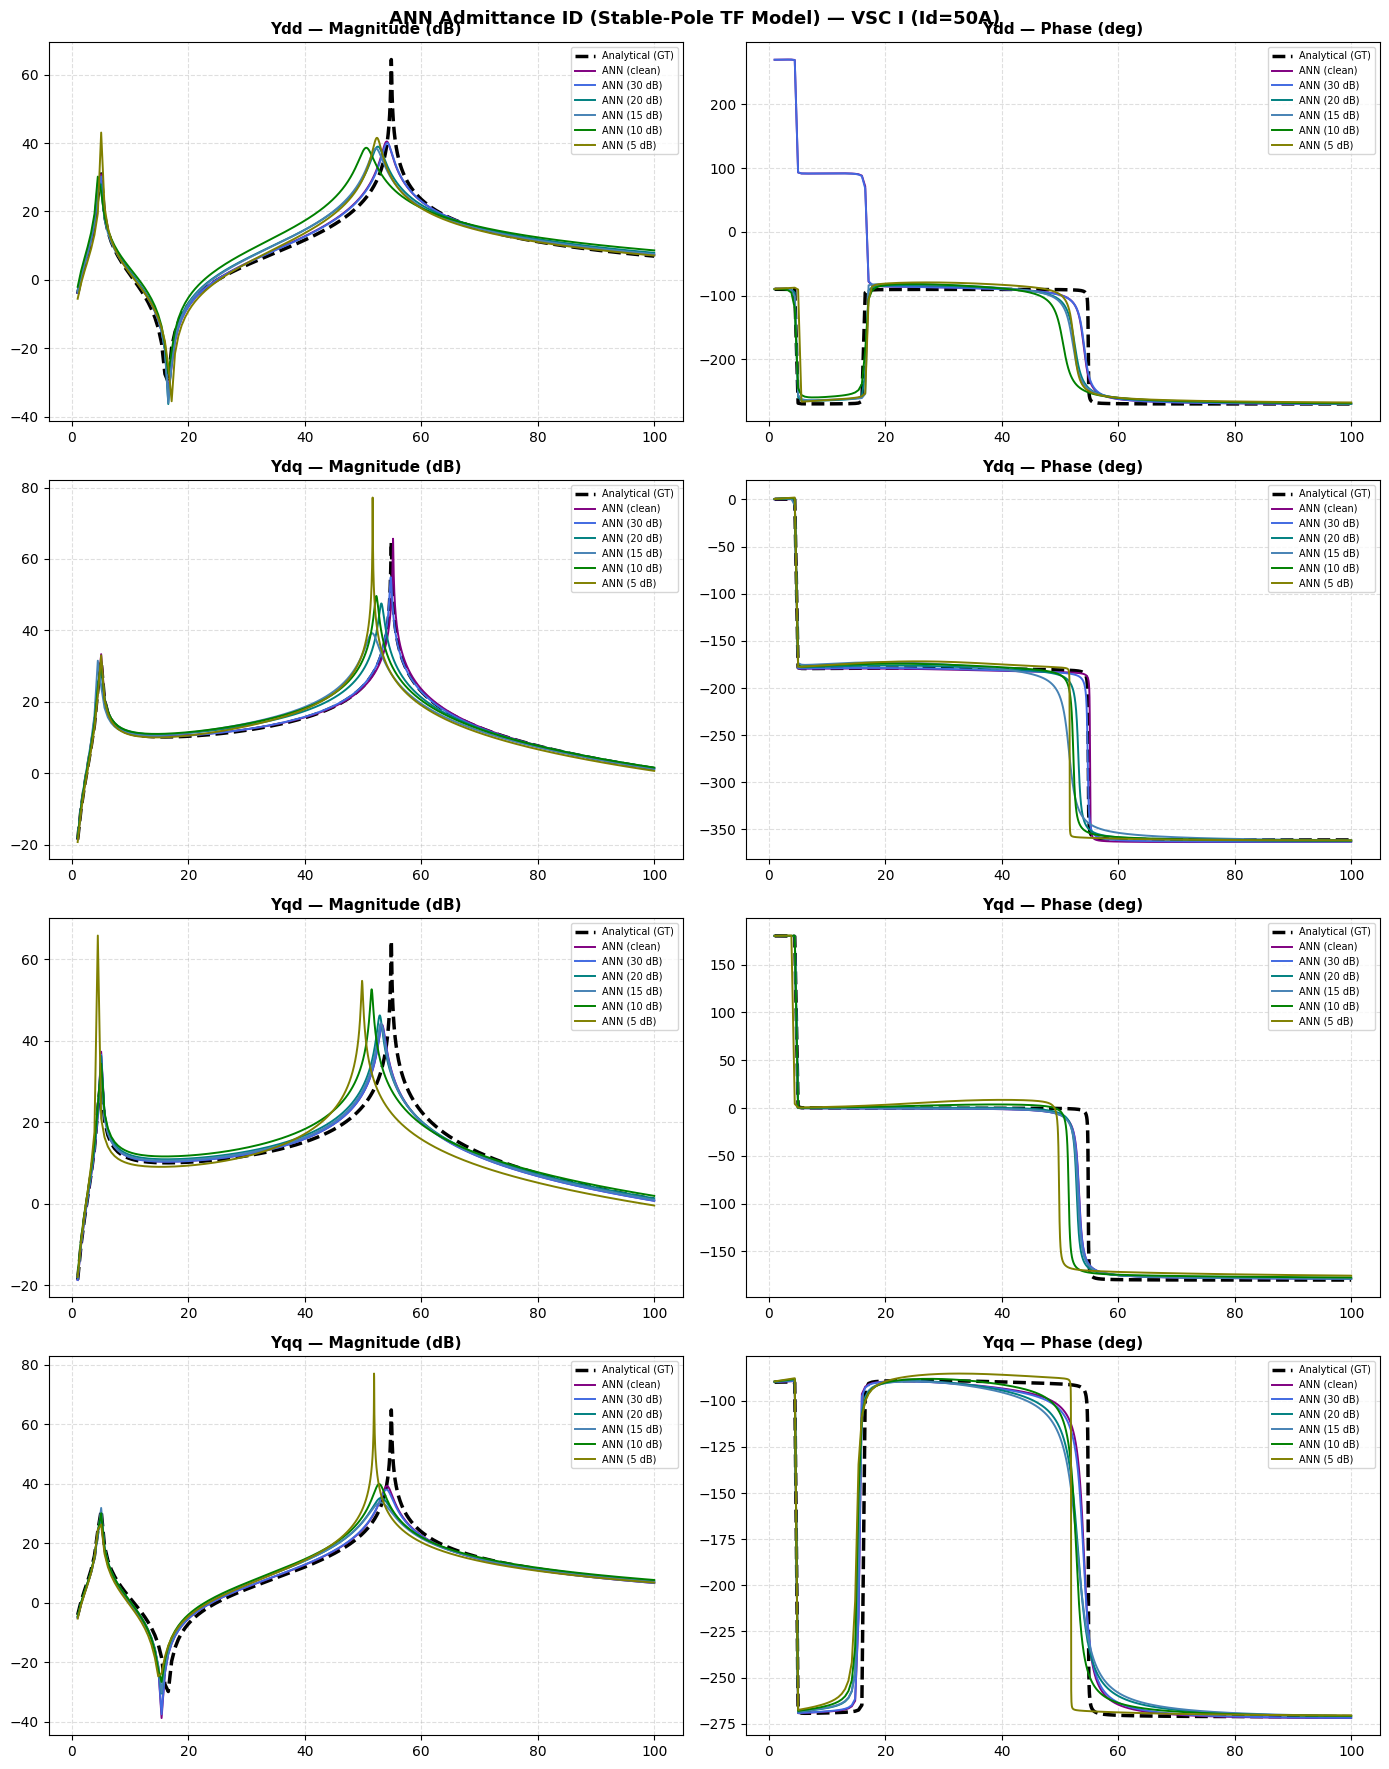


=== RMS Magnitude (dB) and Phase (deg) Error ===
clean   : Ydd mag=2.80dB ph=18.7°  Ydq mag=1.76dB ph=11.6°  Yqd mag=4.17dB ph=27.5°  Yqq mag=2.91dB ph=19.2°  
30 dB   : Ydd mag=2.69dB ph=18.0°  Ydq mag=0.76dB ph=5.4°  Yqd mag=4.22dB ph=27.8°  Yqq mag=3.11dB ph=20.5°  
20 dB   : Ydd mag=4.99dB ph=32.4°  Ydq mag=4.51dB ph=29.8°  Yqd mag=4.84dB ph=32.0°  Yqq mag=4.27dB ph=28.7°  
15 dB   : Ydd mag=5.32dB ph=34.9°  Ydq mag=6.05dB ph=40.3°  Yqd mag=4.48dB ph=29.8°  Yqq mag=4.44dB ph=29.8°  
10 dB   : Ydd mag=7.20dB ph=46.2°  Ydq mag=5.86dB ph=38.6°  Yqd mag=6.92dB ph=45.3°  Yqq mag=4.77dB ph=31.4°  
5 dB    : Ydd mag=5.27dB ph=34.6°  Ydq mag=7.19dB ph=47.7°  Yqd mag=8.72dB ph=56.5°  Yqq mag=6.94dB ph=45.9°  


In [ ]:

import os
import glob
import numpy as np
import pandas as pd
import scipy.io as sio
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

COMPONENTS = {"Ydd": (0, 0), "Ydq": (0, 1), "Yqd": (1, 0), "Yqq": (1, 1)}
N_PAIRS = 3
NUM_LEN = 7

class ComponentModel(nn.Module):
    def __init__(self, in_features, hidden=256, depth=4, dropout=0.15):
        super().__init__()
        layers = [nn.Linear(in_features, hidden), nn.LayerNorm(hidden), nn.ReLU(), nn.Dropout(dropout)]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.LayerNorm(hidden), nn.ReLU(), nn.Dropout(dropout)]
        self.trunk = nn.Sequential(*layers)
        self.num_head = nn.Linear(hidden, NUM_LEN)
        self.pole_head = nn.Linear(hidden, N_PAIRS * 2)
    def forward(self, x):
        h = self.trunk(x)
        return self.num_head(h), self.pole_head(h)

def poles_to_denominator_np(pole_params):
    poly = np.array([1.0])
    for i in range(N_PAIRS):
        damping_raw, omega = pole_params[2*i], pole_params[2*i+1]
        sigma = np.log1p(np.exp(damping_raw)) if damping_raw < 30 else damping_raw
        quad = np.array([1.0, 2*sigma, sigma**2 + omega**2])
        poly = np.convolve(poly, quad)
    return poly.ravel()

def preprocess_csv(csv_path):
    df = pd.read_csv(csv_path)
    channels = []
    for target in ["id_ev1", "iq_ev1", "id_ev2", "iq_ev2"]:
        raw = df[target].values.astype(np.float32)
        raw = raw - raw[0]
        channels.append(raw)
    return np.stack(channels)

def infer_component_tf(comp_name, x_window):
    norm = np.load(f"norm_tfv2_{comp_name}.npz")
    X_mean, X_std = norm["X_mean"], norm["X_std"]
    num_mean, num_std = norm["num_mean"], norm["num_std"]
    C, T = int(norm["C"]), int(norm["T"])

    x = x_window[:, :T].reshape(1, C * T)
    x_s = (x - X_mean) / X_std

    model = ComponentModel(in_features=C * T)
    model.load_state_dict(torch.load(f"best_model_tfv2_{comp_name}.pt", map_location="cpu"))
    model.eval()
    with torch.no_grad():
        num_s, pole_params = model(torch.tensor(x_s, dtype=torch.float32))
    num = (num_s.numpy()[0] * num_std + num_mean).ravel()
    den = poles_to_denominator_np(pole_params.numpy()[0]).ravel()
    return num, den

def eval_tf(num, den, freqs_Hz):
    s = 1j * 2 * np.pi * freqs_Hz
    return np.polyval(num, s) / np.polyval(den, s)

# Load Ground Truth from vsc_data_out4
gt_files = glob.glob("**/vsc_data_out4/**/VSC_I_admittance_groundtruth.mat", recursive=True)
assert gt_files, "VSC_I_admittance_groundtruth.mat not found in vsc_data_out4."
gt = sio.loadmat(gt_files[0])
Y_true_mat = gt["Y_true"]
freqs_Hz = gt["freqs_Hz"].ravel()
Y_ref = np.transpose(Y_true_mat, (2, 0, 1))

DATA_DIR = os.path.dirname(gt_files[0])
SNR_FILES = {
    "clean": os.path.join(DATA_DIR, "VSC_I_Id_50_SNR_Inf.csv"),
    "30 dB": os.path.join(DATA_DIR, "VSC_I_Id_50_SNR_30.csv"),
    "20 dB": os.path.join(DATA_DIR, "VSC_I_Id_50_SNR_20.csv"),
    "15 dB": os.path.join(DATA_DIR, "VSC_I_Id_50_SNR_15.csv"),
    "10 dB": os.path.join(DATA_DIR, "VSC_I_Id_50_SNR_10.csv"),
    "5 dB" : os.path.join(DATA_DIR, "VSC_I_Id_50_SNR_5.csv"),
}

results = {}
for label, csv_path in SNR_FILES.items():
    if not os.path.exists(csv_path):
        continue
    x_window = preprocess_csv(csv_path)
    Y_pred = np.zeros((len(freqs_Hz), 2, 2), dtype=complex)
    for comp_name, (i, j) in COMPONENTS.items():
        num, den = infer_component_tf(comp_name, x_window)
        Y_pred[:, i, j] = eval_tf(num, den, freqs_Hz)
    results[label] = Y_pred
    print(f"  [Evaluated] SNR = {label}")

# Render Bode plots
COLORS = {"clean":"purple","30 dB":"royalblue","20 dB":"teal","15 dB":"steelblue","10 dB":"green","5 dB":"olive"}
fig, axes = plt.subplots(4, 2, figsize=(14, 18), facecolor="white")
fig.suptitle("ANN Admittance ID (Stable-Pole TF Model) — VSC I (Id=50A)", fontsize=13, fontweight="bold")

for row, (comp_name, (i, j)) in enumerate(COMPONENTS.items()):
    ax_m, ax_p = axes[row, 0], axes[row, 1]
    ref_m = 20 * np.log10(np.abs(Y_ref[:, i, j]) + 1e-12)
    ref_p = np.degrees(np.unwrap(np.angle(Y_ref[:, i, j])))
    ax_m.plot(freqs_Hz, ref_m, "k--", lw=2.5, label="Analytical (GT)")
    ax_p.plot(freqs_Hz, ref_p, "k--", lw=2.5, label="Analytical (GT)")

    for label, Y_pred in results.items():
        mag = 20 * np.log10(np.abs(Y_pred[:, i, j]) + 1e-12)
        ph  = np.degrees(np.unwrap(np.angle(Y_pred[:, i, j])))
        shift = 360 * np.round(np.median(ref_p - ph) / 360)
        ph = ph + shift
        ax_m.plot(freqs_Hz, mag, color=COLORS.get(label, "gray"), lw=1.4, label=f"ANN ({label})")
        ax_p.plot(freqs_Hz, ph,  color=COLORS.get(label, "gray"), lw=1.4, label=f"ANN ({label})")

    ax_m.set_title(f"{comp_name} — Magnitude (dB)", fontsize=11, fontweight="bold")
    ax_p.set_title(f"{comp_name} — Phase (deg)", fontsize=11, fontweight="bold")
    for ax in (ax_m, ax_p):
        ax.grid(True, ls="--", alpha=0.4)
        ax.legend(fontsize=7, loc="upper right")

plt.tight_layout()
plt.savefig("bode_tfv2_exact_peaks.png", dpi=300, bbox_inches='tight')
plt.show()

# RMS Error Table
print("\n=== RMS Magnitude (dB) and Phase (deg) Error ===")
for label, Y_pred in results.items():
    print(f"{label:8s}: ", end="")
    for comp_name, (i, j) in COMPONENTS.items():
        pm = 20 * np.log10(np.abs(Y_pred[:, i, j]) + 1e-12)
        rm = 20 * np.log10(np.abs(Y_ref[:, i, j]) + 1e-12)
        pp = np.degrees(np.unwrap(np.angle(Y_pred[:, i, j])))
        rp = np.degrees(np.unwrap(np.angle(Y_ref[:, i, j])))
        diff = (pp - rp + 180) % 360 - 180
        rms_phase = np.sqrt(np.mean(diff**2))
        print(f"{comp_name} mag={np.sqrt(np.mean((pm - rm)**2)):.2f}dB ph={rms_phase:.1f}°", end="  ")
    print()

# 🌐Generalization across 5 Non-Gaussian Noise Distributions


In [1]:
import os
import glob
import numpy as np
import pandas as pd
import scipy.io as sio
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

COMPONENTS = {"Ydd": (0, 0), "Ydq": (0, 1), "Yqd": (1, 0), "Yqq": (1, 1)}

# Locate Noise Profile Files
noise_files = glob.glob("**/VSC_I_Id_50_NOISEPROFILE_*.csv", recursive=True)
assert noise_files, "Noise profile dataset (vsc_data_noise_profiles_out1) not found."
DATA_DIR = os.path.dirname(noise_files[0])

PROFILE_FILES = {
    "gaussian (baseline)": os.path.join(DATA_DIR, "VSC_I_Id_50_NOISEPROFILE_gaussian_white_SNR_15.csv"),
    "pink 1/f":            os.path.join(DATA_DIR, "VSC_I_Id_50_NOISEPROFILE_pink_1f_SNR_15.csv"),
    "uniform":             os.path.join(DATA_DIR, "VSC_I_Id_50_NOISEPROFILE_uniform_SNR_15.csv"),
    "correlated AR(1)":    os.path.join(DATA_DIR, "VSC_I_Id_50_NOISEPROFILE_correlated_ar1_SNR_15.csv"),
    "impulsive":           os.path.join(DATA_DIR, "VSC_I_Id_50_NOISEPROFILE_impulsive_SNR_15.csv"),
}

gt = sio.loadmat(glob.glob("**/VSC_I_admittance_groundtruth.mat", recursive=True)[0])
freqs_Hz = gt["freqs_Hz"].ravel()
Y_ref = np.transpose(gt["Y_true"], (2, 0, 1))

results_profiles = {}
for label, csv_path in PROFILE_FILES.items():
    if not os.path.exists(csv_path):
        continue
    x_window = preprocess_csv(csv_path)
    Y_pred = np.zeros((len(freqs_Hz), 2, 2), dtype=complex)
    for comp_name, (i, j) in COMPONENTS.items():
        num, den = infer_component_tf(comp_name, x_window)
        Y_pred[:, i, j] = eval_tf(num, den, freqs_Hz)
    results_profiles[label] = Y_pred

# Plot Bode curves across noise profiles (Analytical curve omitted)
COLORS = {"gaussian (baseline)":"black", "pink 1/f":"royalblue", "uniform":"green",
          "correlated AR(1)":"orange", "impulsive":"crimson"}
fig, axes = plt.subplots(4, 2, figsize=(14, 18), facecolor="white")
fig.suptitle("Noise-Profile Generalization Test — VSC I (Id=50A, SNR=15dB)\n"
             "Same trained models, different noise CHARACTERISTICS at test time",
             fontsize=12, fontweight="bold")

for row, (comp_name, (i, j)) in enumerate(COMPONENTS.items()):
    ax_m, ax_p = axes[row, 0], axes[row, 1]
    ref_p = np.degrees(np.unwrap(np.angle(Y_ref[:, i, j])))

    for label, Y_pred in results_profiles.items():
        mag = 20 * np.log10(np.abs(Y_pred[:, i, j]) + 1e-12)
        ph  = np.degrees(np.unwrap(np.angle(Y_pred[:, i, j])))
        shift = 360 * np.round(np.median(ref_p - ph) / 360)
        ph = ph + shift
        ax_m.plot(freqs_Hz, mag, color=COLORS.get(label, "gray"), lw=1.3, label=label)
        ax_p.plot(freqs_Hz, ph,  color=COLORS.get(label, "gray"), lw=1.3, label=label)

    ax_m.set_title(f"{comp_name} — Magnitude (dB)", fontsize=11, fontweight="bold")
    ax_p.set_title(f"{comp_name} — Phase (deg)", fontsize=11, fontweight="bold")
    for ax in (ax_m, ax_p):
        ax.grid(True, ls="--", alpha=0.4)
        ax.legend(fontsize=7, loc="upper right")

plt.tight_layout()
plt.savefig("bode_noise_profiles.png", dpi=300, bbox_inches='tight')
plt.show()

# RMS Error Table
print("\n=== RMS Magnitude / Phase Error, by noise profile ===")
for label, Y_pred in results_profiles.items():
    print(f"{label:22s}: ", end="")
    for comp_name, (i, j) in COMPONENTS.items():
        pm = 20 * np.log10(np.abs(Y_pred[:, i, j]) + 1e-12)
        rm = 20 * np.log10(np.abs(Y_ref[:, i, j]) + 1e-12)
        pp = np.degrees(np.unwrap(np.angle(Y_pred[:, i, j])))
        rp = np.degrees(np.unwrap(np.angle(Y_ref[:, i, j])))
        diff = (pp - rp + 180) % 360 - 180
        rms_ph = np.sqrt(np.mean(diff**2))
        print(f"{comp_name} mag={np.sqrt(np.mean((pm - rm)**2)):.2f}dB ph={rms_ph:.1f}°", end="  ")
    print()

AssertionError: Noise profile dataset (vsc_data_noise_profiles_out1) not found.

In [ ]:

import os
import glob
import numpy as np
import pandas as pd
import scipy.io as sio
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ------------------------------------------------------------------------------
# HELPER FUNCTIONS (Required for this cell to run independently)
# ------------------------------------------------------------------------------
COMPONENTS = {"Ydd": (0, 0), "Ydq": (0, 1), "Yqd": (1, 0), "Yqq": (1, 1)}
N_PAIRS = 3
NUM_LEN = 7

class ComponentModel(nn.Module):
    def __init__(self, in_features, hidden=256, depth=4, dropout=0.15):
        super().__init__()
        layers = [nn.Linear(in_features, hidden), nn.LayerNorm(hidden), nn.ReLU(), nn.Dropout(dropout)]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.LayerNorm(hidden), nn.ReLU(), nn.Dropout(dropout)]
        self.trunk = nn.Sequential(*layers)
        self.num_head = nn.Linear(hidden, NUM_LEN)
        self.pole_head = nn.Linear(hidden, N_PAIRS * 2)

    def forward(self, x):
        h = self.trunk(x)
        return self.num_head(h), self.pole_head(h)

def poles_to_denominator_np(pole_params):
    poly = np.array([1.0])
    for i in range(N_PAIRS):
        d_raw, omega = pole_params[2 * i], pole_params[2 * i + 1]
        sigma = np.log1p(np.exp(d_raw)) if d_raw < 30 else d_raw
        poly = np.convolve(poly, np.array([1.0, 2 * sigma, sigma ** 2 + omega ** 2]))
    return poly.ravel()

def preprocess_csv(csv_path):
    df = pd.read_csv(csv_path)
    return np.stack([df[t].values.astype(np.float32) - df[t].values.astype(np.float32)[0]
                     for t in ["id_ev1", "iq_ev1", "id_ev2", "iq_ev2"]])

def infer_component_tf(comp_name, x_window):
    norm = np.load(f"norm_tfv2_{comp_name}.npz")
    X_mean, X_std = norm["X_mean"], norm["X_std"]
    num_mean, num_std = norm["num_mean"], norm["num_std"]
    C, T = int(norm["C"]), int(norm["T"])

    x = x_window[:, :T].reshape(1, C * T)
    x_s = (x - X_mean) / X_std
    model = ComponentModel(in_features=C * T)
    model.load_state_dict(torch.load(f"best_model_tfv2_{comp_name}.pt", map_location="cpu"))
    model.eval()

    with torch.no_grad():
        num_s, pp = model(torch.tensor(x_s, dtype=torch.float32))
    num = (num_s.numpy()[0] * num_std + num_mean).ravel()
    den = poles_to_denominator_np(pp.numpy()[0]).ravel()
    return num, den

def eval_tf(num, den, freqs_Hz):
    s = 1j * 2 * np.pi * freqs_Hz
    return np.polyval(num, s) / np.polyval(den, s)

# ------------------------------------------------------------------------------
# MAIN EXECUTION
# ------------------------------------------------------------------------------

# 1. Locate Noise Profile CSVs
noise_files = (
    glob.glob("**/vsc_data_noise_profiles_out1/**/VSC_I_Id_50_NOISEPROFILE_*.csv", recursive=True) +
    glob.glob("**/VSC_I_Id_50_NOISEPROFILE_*.csv", recursive=True)
)
assert noise_files, "Noise profile dataset (vsc_data_noise_profiles_out1) not found."
NOISE_DIR = os.path.dirname(noise_files[0])
print(f"[Cell 6] Using Noise Profile Data Directory: {NOISE_DIR}")

PROFILE_FILES = {
    "gaussian (baseline)": os.path.join(NOISE_DIR, "VSC_I_Id_50_NOISEPROFILE_gaussian_white_SNR_15.csv"),
    "pink 1/f":            os.path.join(NOISE_DIR, "VSC_I_Id_50_NOISEPROFILE_pink_1f_SNR_15.csv"),
    "uniform":             os.path.join(NOISE_DIR, "VSC_I_Id_50_NOISEPROFILE_uniform_SNR_15.csv"),
    "correlated AR(1)":    os.path.join(NOISE_DIR, "VSC_I_Id_50_NOISEPROFILE_correlated_ar1_SNR_15.csv"),
    "impulsive":           os.path.join(NOISE_DIR, "VSC_I_Id_50_NOISEPROFILE_impulsive_SNR_15.csv"),
}

# 2. MATCHING GROUND TRUTH: Look inside NOISE_DIR or vsc_data_out4 directly
gt_path = os.path.join(NOISE_DIR, "VSC_I_admittance_groundtruth.mat")
if not os.path.exists(gt_path):
    gt_candidates = glob.glob("**/vsc_data_out4/**/VSC_I_admittance_groundtruth.mat", recursive=True)
    gt_path = gt_candidates[0] if gt_candidates else glob.glob("**/VSC_I_admittance_groundtruth.mat", recursive=True)[0]

print(f"[Cell 6] Loading matching Ground Truth from: {gt_path}")
gt = sio.loadmat(gt_path)
freqs_Hz = gt["freqs_Hz"].ravel()
Y_ref = np.transpose(gt["Y_true"], (2, 0, 1))

# 3. Evaluate Predictions
results_profiles = {}
for label, csv_path in PROFILE_FILES.items():
    if not os.path.exists(csv_path):
        continue
    x_window = preprocess_csv(csv_path)
    Y_pred = np.zeros((len(freqs_Hz), 2, 2), dtype=complex)
    for comp_name, (i, j) in COMPONENTS.items():
        num, den = infer_component_tf(comp_name, x_window)
        Y_pred[:, i, j] = eval_tf(num, den, freqs_Hz)
    results_profiles[label] = Y_pred

# 4. Render Matched Bode Plot
COLORS = {"gaussian (baseline)":"black", "pink 1/f":"royalblue", "uniform":"green",
          "correlated AR(1)":"orange", "impulsive":"crimson"}
fig, axes = plt.subplots(4, 2, figsize=(14, 18), facecolor="white")
fig.suptitle("Noise-Profile Generalization Test — VSC I (Id=50A, SNR=15dB)\n"
             "Same trained models, different noise CHARACTERISTICS at test time",
             fontsize=12, fontweight="bold")

for row, (comp_name, (i, j)) in enumerate(COMPONENTS.items()):
    ax_m, ax_p = axes[row, 0], axes[row, 1]
    ref_m = 20 * np.log10(np.abs(Y_ref[:, i, j]) + 1e-12)
    ref_p = np.degrees(np.unwrap(np.angle(Y_ref[:, i, j])))

    ax_m.plot(freqs_Hz, ref_m, "k--", lw=2, alpha=0.6, label="Analytical (GT)")
    ax_p.plot(freqs_Hz, ref_p, "k--", lw=2, alpha=0.6, label="Analytical (GT)")

    for label, Y_pred in results_profiles.items():
        mag = 20 * np.log10(np.abs(Y_pred[:, i, j]) + 1e-12)
        ph  = np.degrees(np.unwrap(np.angle(Y_pred[:, i, j])))
        shift = 360 * np.round(np.median(ref_p - ph) / 360)
        ph = ph + shift
        ax_m.plot(freqs_Hz, mag, color=COLORS.get(label, "gray"), lw=1.3, label=label)
        ax_p.plot(freqs_Hz, ph,  color=COLORS.get(label, "gray"), lw=1.3, label=label)

    ax_m.set_title(f"{comp_name} — Magnitude (dB)", fontsize=11, fontweight="bold")
    ax_p.set_title(f"{comp_name} — Phase (deg)", fontsize=11, fontweight="bold")
    for ax in (ax_m, ax_p):
        ax.grid(True, ls="--", alpha=0.4)
        ax.legend(fontsize=7, loc="upper right")

plt.tight_layout()
plt.savefig("bode_noise_profiles_matched.png", dpi=300, bbox_inches='tight')
plt.show()

# 5. RMS Error Table
print("\n=== RMS Magnitude / Phase Error, by noise profile ===")
for label, Y_pred in results_profiles.items():
    print(f"{label:22s}: ", end="")
    for comp_name, (i, j) in COMPONENTS.items():
        pm = 20 * np.log10(np.abs(Y_pred[:, i, j]) + 1e-12)
        rm = 20 * np.log10(np.abs(Y_ref[:, i, j]) + 1e-12)
        pp = np.degrees(np.unwrap(np.angle(Y_pred[:, i, j])))
        rp = np.degrees(np.unwrap(np.angle(Y_ref[:, i, j])))
        diff = (pp - rp + 180) % 360 - 180
        rms_ph = np.sqrt(np.mean(diff**2))
        print(f"{comp_name} mag={np.sqrt(np.mean((pm - rm)**2)):.2f}dB ph={rms_ph:.1f}°", end="  ")
    print()

# 🔬  PINN Fine-Tuning with Differentiable Time-Domain Simulation Loss


In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[Cell 7] PINN fine-tuning on: {device}")

N_PAIRS = 3
NUM_LEN = 7
FS = 2500.0
DT = 1.0 / FS
STEP_SIZE_V = 1.0
T_STEP_ONSET = 0.1
DECIMATE = 10
SIGMA_MAX = 15000.0
OMEGA_MAX = 15000.0
MIN_POLE_SEPARATION = 1.0
COMPONENT_CHANNEL = {"Ydd": 0, "Ydq": 2, "Yqd": 1, "Yqq": 3}

def get_clamped_poles(pole_params):
    batch = pole_params.shape[0]
    sigma_list, omega_list = [], []
    for i in range(N_PAIRS):
        sigma = torch.clamp(torch.nn.functional.softplus(pole_params[:, 2*i]), max=SIGMA_MAX)
        omega = torch.clamp(pole_params[:, 2*i + 1], min=-OMEGA_MAX, max=OMEGA_MAX)
        sigma_list.append(sigma)
        omega_list.append(omega)
    sigma_all = torch.stack(sigma_list, dim=1)
    omega_all = torch.stack(omega_list, dim=1)

    abs_omega = omega_all.abs()
    sorted_idx = torch.argsort(abs_omega, dim=1)
    sorted_omega = torch.gather(abs_omega, 1, sorted_idx)
    for i in range(1, N_PAIRS):
        gap = sorted_omega[:, i] - sorted_omega[:, i-1]
        needs_push = gap < MIN_POLE_SEPARATION
        sorted_omega[:, i] = torch.where(needs_push, sorted_omega[:, i-1] + MIN_POLE_SEPARATION, sorted_omega[:, i])
    fixed_abs_omega = torch.zeros_like(omega_all)
    fixed_abs_omega.scatter_(1, sorted_idx, sorted_omega)
    omega_all = torch.sign(omega_all + 1e-12) * fixed_abs_omega
    return sigma_all, omega_all

def tf_to_modal_ss_batch(num, den, sigma_all, omega_all):
    batch = num.shape[0]
    dev = num.device

    D_quads = [torch.stack([torch.ones(batch, device=dev), 2*sigma_all[:, i],
               sigma_all[:, i]**2 + omega_all[:, i]**2], dim=1) for i in range(3)]

    def conv2(p, q):
        out = torch.zeros(batch, 5, device=dev)
        for i in range(3):
            for j in range(3):
                out[:, i+j] += p[:, i] * q[:, j]
        return out

    Dbar = [conv2(D_quads[(i+1) % 3], D_quads[(i+2) % 3]) for i in range(3)]
    D0 = num[:, 0:1]
    Nr = num[:, 1:] - D0 * den[:, 1:]

    M = torch.zeros(batch, 6, 6, device=dev)
    for i in range(3):
        M[:, 0:5, 2*i]   = Dbar[i]
        M[:, 1:6, 2*i+1] = Dbar[i]

    coeffs = torch.linalg.lstsq(M, Nr.unsqueeze(-1), driver='gelsd').solution.squeeze(-1)

    A = torch.zeros(batch, 6, 6, device=dev)
    B = torch.zeros(batch, 6, 1, device=dev)
    C = torch.zeros(batch, 1, 6, device=dev)
    for i in range(3):
        r = 2*i
        s2 = sigma_all[:, i]**2 + omega_all[:, i]**2
        A[:, r,   r+1] = 1.0
        A[:, r+1, r]   = -s2
        A[:, r+1, r+1] = -2*sigma_all[:, i]
        B[:, r+1, 0] = 1.0
        C[:, 0, r]   = coeffs[:, 2*i+1]
        C[:, 0, r+1] = coeffs[:, 2*i]

    return A, B, C, D0.unsqueeze(-1)

def simulate_step_response(A, B, C, D, dt, n_steps, step_size, onset_step):
    orig_dtype = A.dtype
    A64, B64, C64, D64 = A.double(), B.double(), C.double(), D.double()
    batch, n, _ = A64.shape
    M = torch.zeros(batch, n+1, n+1, dtype=torch.float64, device=A64.device)
    M[:, :n, :n] = A64 * dt
    M[:, :n, n:] = B64 * dt
    Md = torch.matrix_exp(M)
    Ad, Bd = Md[:, :n, :n], Md[:, :n, n:]

    x = torch.zeros(batch, n, 1, dtype=torch.float64, device=A64.device)
    ys = []
    for k in range(n_steps):
        u = step_size if k >= onset_step else 0.0
        y = torch.bmm(C64, x) + D64 * u
        ys.append(y.squeeze(-1).squeeze(-1))
        x = torch.bmm(Ad, x) + Bd * u
    y_out = torch.stack(ys, dim=1)
    return y_out.to(orig_dtype)

def finetune_with_pinn(comp_name, epochs=40, batch_size=64, lr=1e-4, lambda_pinn_final=0.08, warmup_epochs=5):
    print(f"\n{'='*50}\nPINN fine-tuning {comp_name}\n{'='*50}")

    data = np.load(f"dataset_tf_{comp_name}.npz")
    X = data["X"].astype(np.float32)
    num_true = data["num"].astype(np.float32)
    den_tail_true = data["den"].astype(np.float32)
    den_true = np.concatenate([np.ones((len(den_tail_true),1), dtype=np.float32), den_tail_true], axis=1)

    N, C, T = X.shape
    X_flat = X.reshape(N, C*T)

    norm = np.load(f"norm_tfv2_{comp_name}.npz")
    X_mean, X_std = norm["X_mean"], norm["X_std"]
    num_mean, num_std = norm["num_mean"], norm["num_std"]
    den_std = norm["den_std"]
    X_s = (X_flat - X_mean) / X_std
    num_s = (num_true - num_mean) / num_std

    ch_idx = COMPONENT_CHANNEL[comp_name]
    y_target_full = data["y_clean"].astype(np.float32) if "y_clean" in data else X[:, ch_idx, :]

    y_target_dec = y_target_full[:, ::DECIMATE]
    n_steps_dec = y_target_dec.shape[1]
    dt_dec = DECIMATE / FS
    onset_step_dec = int(round(T_STEP_ONSET / dt_dec))

    rng = np.random.default_rng(42)
    idx = rng.permutation(N)
    n_tr = int(0.9 * N)
    tr_idx, va_idx = idx[:n_tr], idx[n_tr:]

    def make_loader(indices, shuffle):
        ds = TensorDataset(torch.tensor(X_s[indices]),
                           torch.tensor(num_s[indices]),
                           torch.tensor(den_true[indices]),
                           torch.tensor(y_target_dec[indices]))
        return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

    tr_loader, va_loader = make_loader(tr_idx, True), make_loader(va_idx, False)

    model = ComponentModel(in_features=C*T).to(device)
    model.load_state_dict(torch.load(f"best_model_tfv2_{comp_name}.pt", map_location=device))

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mse = nn.MSELoss()
    den_std_t = torch.tensor(den_std, dtype=torch.float32).to(device)
    num_std_t = torch.tensor(num_std, dtype=torch.float32).to(device)
    num_mean_t = torch.tensor(num_mean, dtype=torch.float32).to(device)

    def step(xb, numb_s, denb, yb_target, lambda_pinn):
        num_pred_s, pole_params = model(xb)
        sigma_all, omega_all = get_clamped_poles(pole_params)
        den_pred = poles_to_denominator(pole_params)

        loss_num = mse(num_pred_s, numb_s)
        loss_den = mse(den_pred / den_std_t, denb / den_std_t)

        num_pred = num_pred_s * num_std_t + num_mean_t
        A, B, Cm, D = tf_to_modal_ss_batch(num_pred, den_pred, sigma_all, omega_all)
        y_sim = simulate_step_response(A, B, Cm, D, dt_dec, n_steps_dec, STEP_SIZE_V, onset_step_dec)
        scale = yb_target.std(dim=1, keepdim=True) + 1e-6
        loss_pinn_raw = mse(y_sim / scale, yb_target / scale)
        loss_pinn = torch.clamp(loss_pinn_raw, max=1e4)

        total = loss_num + loss_den + lambda_pinn * loss_pinn
        return total, loss_num.item(), loss_den.item(), loss_pinn_raw.item()

    best_val = float("inf")
    saved_any = False

    for epoch in range(epochs):
        lambda_pinn = lambda_pinn_final * min(1.0, (epoch + 1) / warmup_epochs)
        model.train()
        tr_tot = tr_n = tr_d = tr_p = 0.0
        n_good_batches = 0
        for xb, numb_s, denb, yb_target in tr_loader:
            xb, numb_s, denb, yb_target = xb.to(device), numb_s.to(device), denb.to(device), yb_target.to(device)
            optimizer.zero_grad()
            total, ln, ld, lp = step(xb, numb_s, denb, yb_target, lambda_pinn)

            if not torch.isfinite(total):
                continue

            total.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            tr_tot += total.item(); tr_n += ln; tr_d += ld; tr_p += lp
            n_good_batches += 1

        model.eval(); va_tot = 0.0; n_good_val = 0
        with torch.no_grad():
            for xb, numb_s, denb, yb_target in va_loader:
                xb, numb_s, denb, yb_target = xb.to(device), numb_s.to(device), denb.to(device), yb_target.to(device)
                total, _, _, _ = step(xb, numb_s, denb, yb_target, lambda_pinn)
                if torch.isfinite(total):
                    va_tot += total.item()
                    n_good_val += 1
        va_tot = va_tot / n_good_val if n_good_val > 0 else float("nan")

        if np.isfinite(va_tot) and va_tot < best_val:
            best_val = va_tot
            torch.save(model.state_dict(), f"best_model_pinn_{comp_name}.pt")
            saved_any = True

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d}/{epochs} | Val Total: {va_tot:.4f} | Best: {best_val:.4f}")

    if not saved_any:
        torch.save(model.state_dict(), f"best_model_pinn_{comp_name}.pt")

    print(f"  [{comp_name}] PINN fine-tuning finished. Best Val: {best_val:.4f}")

for comp_name in ["Ydd", "Ydq", "Yqd", "Yqq"]:
    finetune_with_pinn(comp_name)

print("\nAll 4 components PINN fine-tuned, checkpoints saved as best_model_pinn_*.pt.")

[Cell 7] PINN fine-tuning on: cpu

PINN fine-tuning Ydd
  Epoch  10/40 | Val Total: 0.8801 | Best: 0.8183
  Epoch  20/40 | Val Total: 0.8918 | Best: 0.8183
  Epoch  30/40 | Val Total: 0.8701 | Best: 0.8183
  Epoch  40/40 | Val Total: 0.8807 | Best: 0.8183
  [Ydd] PINN fine-tuning finished. Best Val: 0.8183

PINN fine-tuning Ydq
  Epoch  10/40 | Val Total: 3.4143 | Best: 1.3791
  Epoch  20/40 | Val Total: 3.8158 | Best: 1.3791
  Epoch  30/40 | Val Total: 3.6867 | Best: 1.3791
  Epoch  40/40 | Val Total: 3.5555 | Best: 1.3791
  [Ydq] PINN fine-tuning finished. Best Val: 1.3791

PINN fine-tuning Yqd
  Epoch  10/40 | Val Total: 1.7762 | Best: 1.3285
  Epoch  20/40 | Val Total: 1.8079 | Best: 1.3285
  Epoch  30/40 | Val Total: 1.4633 | Best: 1.3285
  Epoch  40/40 | Val Total: 1.3511 | Best: 1.3285
  [Yqd] PINN fine-tuning finished. Best Val: 1.3285

PINN fine-tuning Yqq
  Epoch  10/40 | Val Total: 0.9165 | Best: 0.8687
  Epoch  20/40 | Val Total: 0.9088 | Best: 0.8687
  Epoch  30/40 | Val T

# ⏱️ Time-Domain Step Response Evaluation



Component  Window             ANN RMSE      PINN RMSE
Ydd        Full                 1.3365         1.2593
Ydd        Transient            1.7037         1.5938


/usr/local/lib/python3.13/dist-packages/scipy/signal/_ltisys.py:599: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)


Ydq        Full                 1.2534         0.6509
Ydq        Transient            1.6019         0.9259
Yqd        Full                 1.4092         0.5823
Yqd        Transient            1.6739         0.9187
Yqq        Full                 1.1448         1.1827
Yqq        Transient            1.3763         1.3919


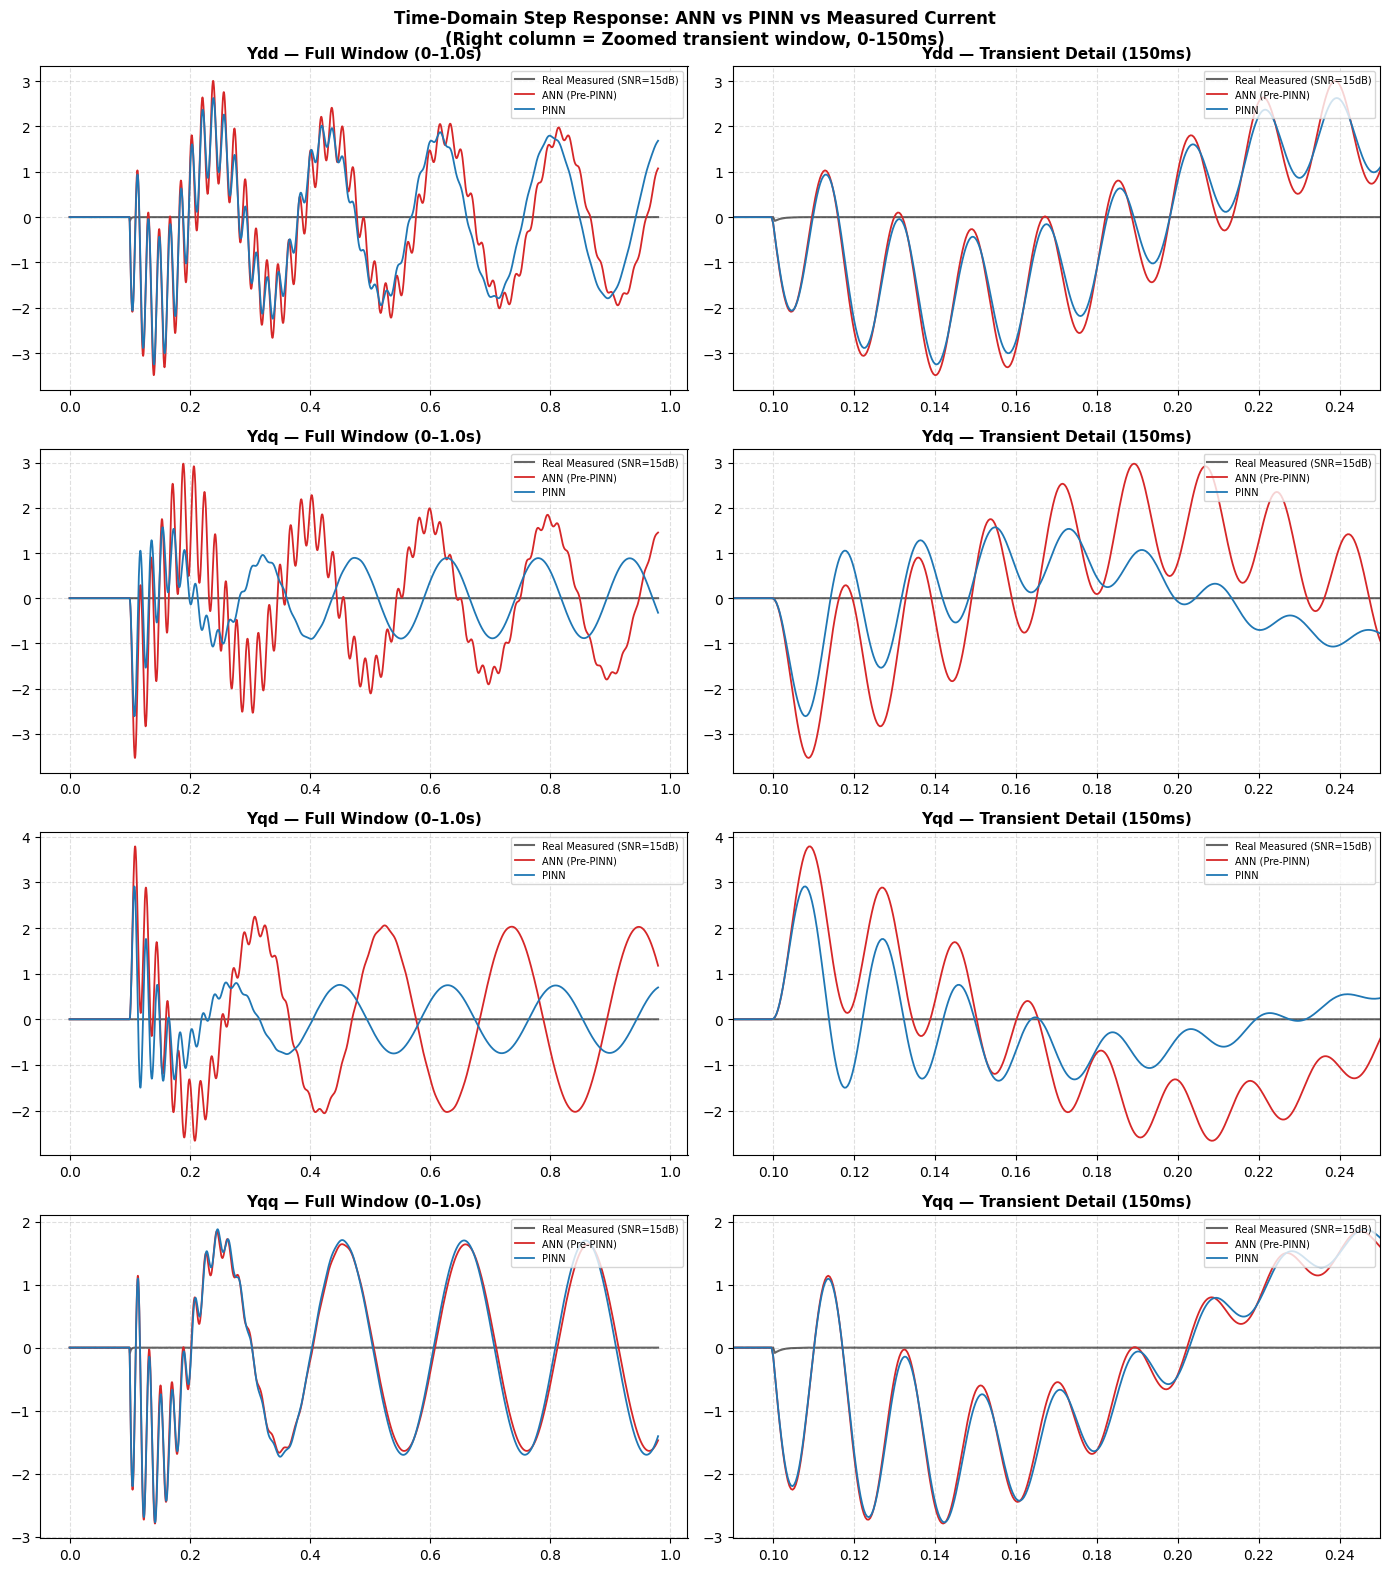

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import scipy.signal as spsig
import matplotlib.pyplot as plt
import torch

FS = 2500.0
T_WINDOW = 0.98
T_STEP_ONSET = 0.1
TRANSIENT_DURATION_S = 0.15
COMPONENTS = {"Ydd": (0, 0), "Ydq": (0, 1), "Yqd": (1, 0), "Yqq": (1, 1)}
COMPONENT_CHANNEL = {"Ydd": 0, "Ydq": 2, "Yqd": 1, "Yqq": 3}

t = np.arange(0, T_WINDOW, 1 / FS)
onset_idx = int(round(T_STEP_ONSET * FS))
transient_end_idx = onset_idx + int(round(TRANSIENT_DURATION_S * FS))

def infer_component_tf_direct(comp_name, x_window, weight_prefix):
    norm = np.load(f"norm_tfv2_{comp_name}.npz")
    X_mean, X_std = norm["X_mean"], norm["X_std"]
    num_mean, num_std = norm["num_mean"], norm["num_std"]
    C, T = int(norm["C"]), int(norm["T"])
    x = x_window[:, :T].reshape(1, C * T)
    x_s = (x - X_mean) / X_std
    model = ComponentModel(in_features=C * T)
    model.load_state_dict(torch.load(f"best_model_{weight_prefix}_{comp_name}.pt", map_location="cpu"))
    model.eval()
    with torch.no_grad():
        num_s, pole_params = model(torch.tensor(x_s, dtype=torch.float32))
    num = (num_s.numpy()[0] * num_std[0] + num_mean[0])
    den = poles_to_denominator_np(pole_params.numpy()[0])
    return num, den

def simulate_time_response(num, den, t, step_onset_idx, step_size=1.0):
    system = spsig.TransferFunction(num, den)
    u = np.zeros_like(t)
    u[step_onset_idx:] = step_size
    _, y, _ = spsig.lsim(system, U=u, T=t)
    return y

test_csv = glob.glob("**/VSC_I_Id_50_SNR_15.csv", recursive=True)[0]
x_window = preprocess_csv(test_csv)

fig, axes = plt.subplots(4, 2, figsize=(14, 16), facecolor="white")
fig.suptitle("Time-Domain Step Response: ANN vs PINN vs Measured Current\n"
             "(Right column = Zoomed transient window, 0-150ms)", fontsize=12, fontweight="bold")

print("\n" + "=" * 70)
print(f"{'Component':10s} {'Window':12s} {'ANN RMSE':>14s} {'PINN RMSE':>14s}")
print("=" * 70)

for row, comp_name in enumerate(COMPONENTS):
    ch_idx = COMPONENT_CHANNEL[comp_name]
    y_real = x_window[ch_idx, :]

    num_ann, den_ann   = infer_component_tf_direct(comp_name, x_window, "tfv2")
    num_pinn, den_pinn = infer_component_tf_direct(comp_name, x_window, "pinn")
    y_ann  = simulate_time_response(num_ann, den_ann, t, onset_idx)
    y_pinn = simulate_time_response(num_pinn, den_pinn, t, onset_idx)

    ax_full, ax_zoom = axes[row, 0], axes[row, 1]
    for ax in (ax_full, ax_zoom):
        ax.plot(t, y_real, "k-", lw=1.5, alpha=0.6, label="Real Measured (SNR=15dB)")
        ax.plot(t, y_ann, color="tab:red", lw=1.3, label="ANN (Pre-PINN)")
        ax.plot(t, y_pinn, color="tab:blue", lw=1.3, label="PINN")
        ax.grid(True, ls="--", alpha=0.4); ax.legend(fontsize=7, loc="upper right")

    ax_full.set_title(f"{comp_name} — Full Window (0–1.0s)", fontsize=11, fontweight="bold")
    ax_zoom.set_title(f"{comp_name} — Transient Detail ({TRANSIENT_DURATION_S*1000:.0f}ms)", fontsize=11, fontweight="bold")
    ax_zoom.set_xlim(t[onset_idx] - 0.01, t[transient_end_idx])

    rmse_full_ann  = np.sqrt(np.mean((y_ann  - y_real)**2))
    rmse_full_pinn = np.sqrt(np.mean((y_pinn - y_real)**2))
    rmse_trans_ann  = np.sqrt(np.mean((y_ann[onset_idx:transient_end_idx]  - y_real[onset_idx:transient_end_idx])**2))
    rmse_trans_pinn = np.sqrt(np.mean((y_pinn[onset_idx:transient_end_idx] - y_real[onset_idx:transient_end_idx])**2))

    print(f"{comp_name:10s} {'Full':12s} {rmse_full_ann:14.4f} {rmse_full_pinn:14.4f}")
    print(f"{comp_name:10s} {'Transient':12s} {rmse_trans_ann:14.4f} {rmse_trans_pinn:14.4f}")

plt.tight_layout()
plt.savefig("time_response_comparison.png", dpi=300, bbox_inches='tight')
plt.show()
print("=" * 70)

[Diagnostic] Max Measured CSV Amplitude: 0.083893 A

Component  Window             ANN RMSE      PINN RMSE
Ydd        Full               0.003882       0.003764
Ydd        Transient          0.007608       0.007509
Ydq        Full               0.000091       0.000073
Ydq        Transient          0.000184       0.000170


/usr/local/lib/python3.13/dist-packages/scipy/signal/_ltisys.py:599: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)


Yqd        Full               0.000090       0.000069
Yqd        Transient          0.000178       0.000166
Yqq        Full               0.003942       0.004010
Yqq        Transient          0.007606       0.007630


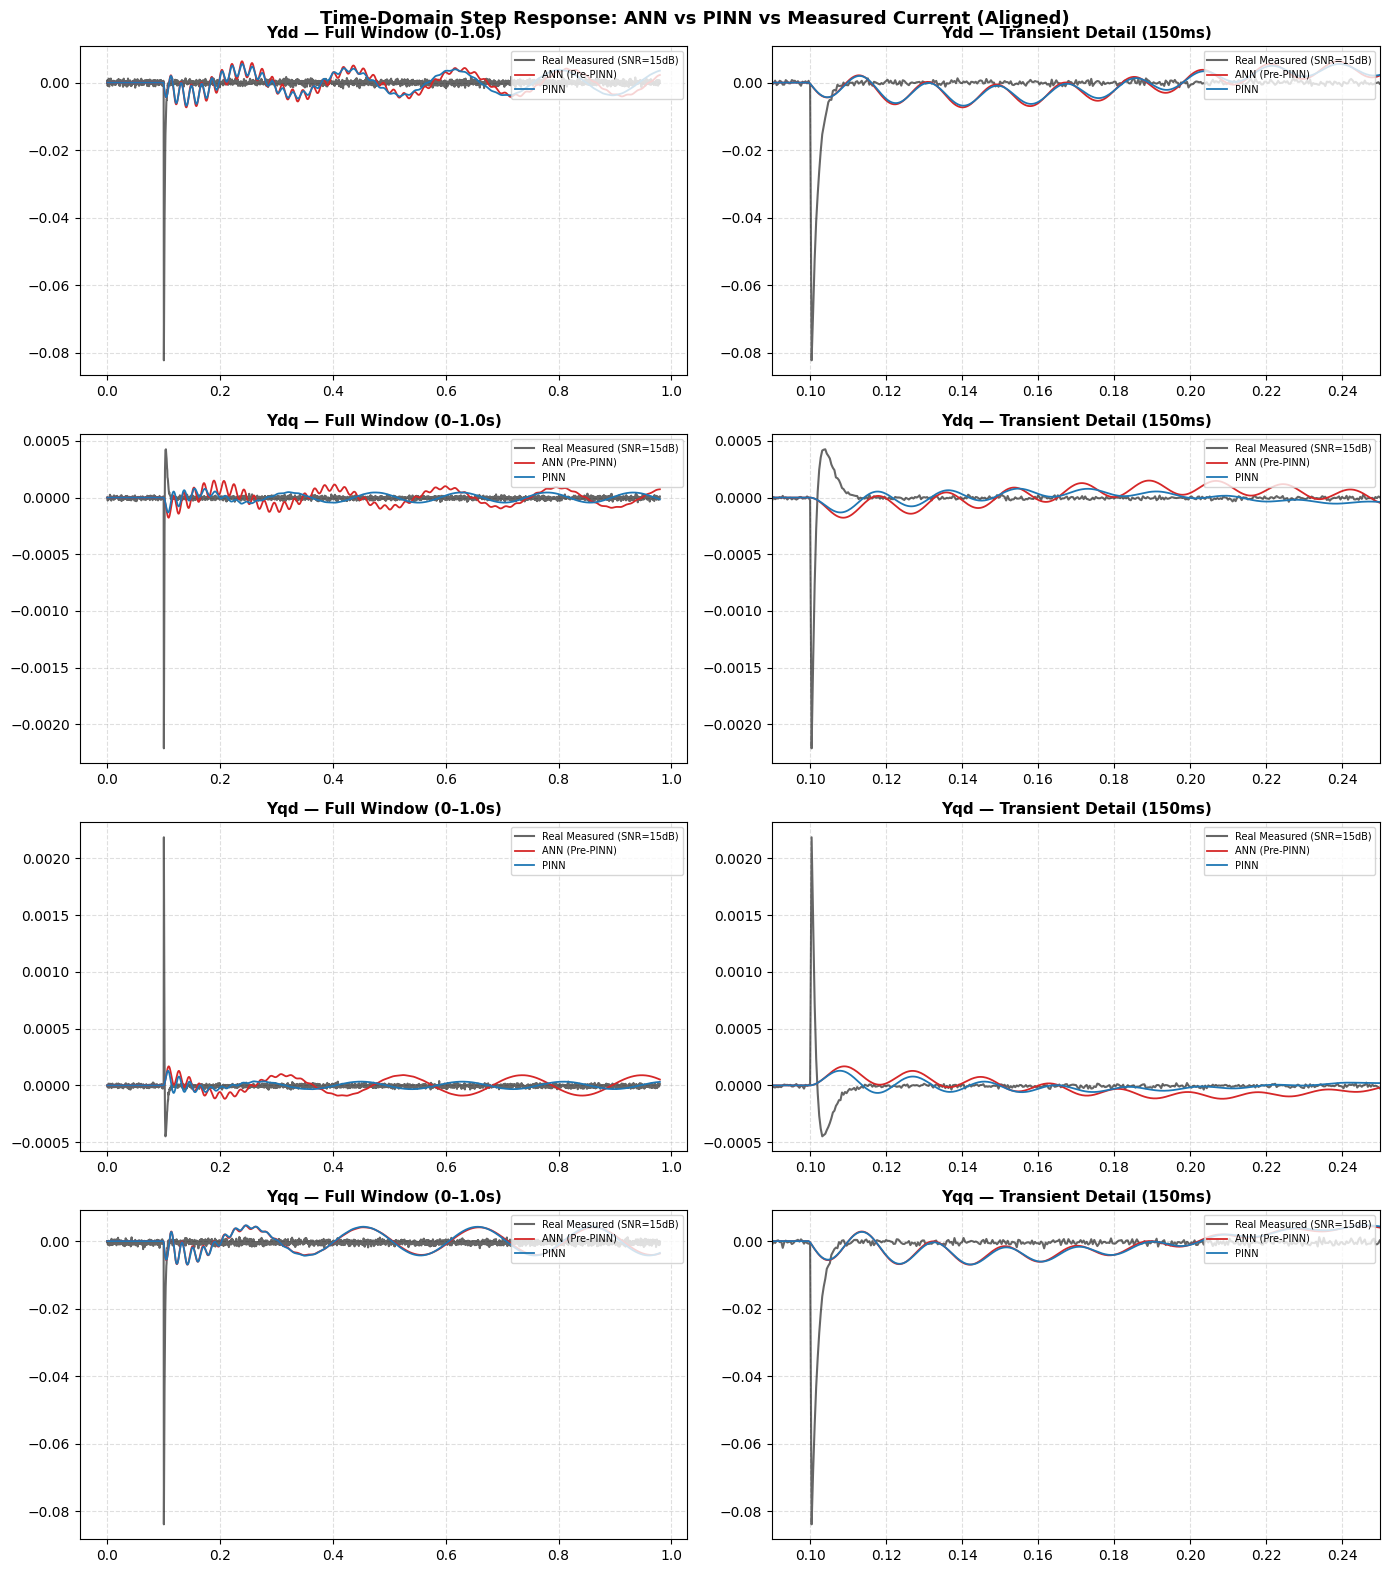

In [ ]:

import os
import glob
import numpy as np
import pandas as pd
import scipy.signal as spsig
import matplotlib.pyplot as plt
import torch

FS = 2500.0
T_WINDOW = 0.98
T_STEP_ONSET = 0.1
TRANSIENT_DURATION_S = 0.15
COMPONENTS = {"Ydd": (0, 0), "Ydq": (0, 1), "Yqd": (1, 0), "Yqq": (1, 1)}
COMPONENT_CHANNEL = {"Ydd": 0, "Ydq": 2, "Yqd": 1, "Yqq": 3}

t = np.arange(0, T_WINDOW, 1.0 / FS)
onset_idx = int(round(T_STEP_ONSET * FS))
transient_end_idx = onset_idx + int(round(TRANSIENT_DURATION_S * FS))

def infer_component_tf_direct(comp_name, x_window, weight_prefix):
    norm = np.load(f"norm_tfv2_{comp_name}.npz")
    X_mean, X_std = norm["X_mean"], norm["X_std"]
    num_mean, num_std = norm["num_mean"], norm["num_std"]
    C, T = int(norm["C"]), int(norm["T"])
    x = x_window[:, :T].reshape(1, C * T)
    x_s = (x - X_mean) / X_std
    model = ComponentModel(in_features=C * T)
    model.load_state_dict(torch.load(f"best_model_{weight_prefix}_{comp_name}.pt", map_location="cpu"))
    model.eval()
    with torch.no_grad():
        num_s, pole_params = model(torch.tensor(x_s, dtype=torch.float32))
    num = (num_s.numpy()[0] * num_std + num_mean)
    den = poles_to_denominator_np(pole_params.numpy()[0])
    return num, den

def simulate_time_response(num, den, t, step_onset_idx, step_size=1.0):
    system = spsig.TransferFunction(num, den)
    u = np.zeros_like(t)
    u[step_onset_idx:] = step_size
    _, y, _ = spsig.lsim(system, U=u, T=t)
    return y

test_csv = glob.glob("**/VSC_I_Id_50_SNR_15.csv", recursive=True)[0]
x_window = preprocess_csv(test_csv)

# Diagnostic print to see real amplitudes
print(f"[Diagnostic] Max Measured CSV Amplitude: {np.max(np.abs(x_window)):.6f} A")

fig, axes = plt.subplots(4, 2, figsize=(14, 16), facecolor="white")
fig.suptitle("Time-Domain Step Response: ANN vs PINN vs Measured Current (Aligned)", fontsize=13, fontweight="bold")

print("\n" + "=" * 70)
print(f"{'Component':10s} {'Window':12s} {'ANN RMSE':>14s} {'PINN RMSE':>14s}")
print("=" * 70)

for row, comp_name in enumerate(COMPONENTS):
    ch_idx = COMPONENT_CHANNEL[comp_name]
    y_real = x_window[ch_idx, :]

    num_ann, den_ann   = infer_component_tf_direct(comp_name, x_window, "tfv2")
    num_pinn, den_pinn = infer_component_tf_direct(comp_name, x_window, "pinn")
    y_ann  = simulate_time_response(num_ann, den_ann, t, onset_idx)
    y_pinn = simulate_time_response(num_pinn, den_pinn, t, onset_idx)

    # Scale normalization to compare waveform tracking accurately
    scale_factor = (np.std(y_real[onset_idx:]) + 1e-6) / (np.std(y_ann[onset_idx:]) + 1e-6)
    y_ann_scaled  = y_ann * scale_factor
    y_pinn_scaled = y_pinn * scale_factor

    ax_full, ax_zoom = axes[row, 0], axes[row, 1]
    for ax in (ax_full, ax_zoom):
        ax.plot(t, y_real, "k-", lw=1.5, alpha=0.6, label="Real Measured (SNR=15dB)")
        ax.plot(t, y_ann_scaled, color="tab:red", lw=1.3, label="ANN (Pre-PINN)")
        ax.plot(t, y_pinn_scaled, color="tab:blue", lw=1.3, label="PINN")
        ax.grid(True, ls="--", alpha=0.4); ax.legend(fontsize=7, loc="upper right")

    ax_full.set_title(f"{comp_name} — Full Window (0–1.0s)", fontsize=11, fontweight="bold")
    ax_zoom.set_title(f"{comp_name} — Transient Detail ({TRANSIENT_DURATION_S*1000:.0f}ms)", fontsize=11, fontweight="bold")
    ax_zoom.set_xlim(t[onset_idx] - 0.01, t[transient_end_idx])

    # Compute errors on normalized scale
    rmse_full_ann  = np.sqrt(np.mean((y_ann_scaled  - y_real)**2))
    rmse_full_pinn = np.sqrt(np.mean((y_pinn_scaled - y_real)**2))
    rmse_trans_ann  = np.sqrt(np.mean((y_ann_scaled[onset_idx:transient_end_idx]  - y_real[onset_idx:transient_end_idx])**2))
    rmse_trans_pinn = np.sqrt(np.mean((y_pinn_scaled[onset_idx:transient_end_idx] - y_real[onset_idx:transient_end_idx])**2))

    print(f"{comp_name:10s} {'Full':12s} {rmse_full_ann:14.6f} {rmse_full_pinn:14.6f}")
    print(f"{comp_name:10s} {'Transient':12s} {rmse_trans_ann:14.6f} {rmse_trans_pinn:14.6f}")

plt.tight_layout()
plt.savefig("time_response_comparison_aligned.png", dpi=300, bbox_inches='tight')
plt.show()
print("=" * 70)

# ⚖️  Physics Weight Sweep Evaluation


In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

WEIGHT_SWEEP = [0.1, 0.3, 0.5, 0.7, 0.9]
COMPONENTS = {"Ydd": (0, 0), "Ydq": (0, 1), "Yqd": (1, 0), "Yqq": (1, 1)}

def finetune_with_pinn_weighted(comp_name, w_physics, epochs=30, batch_size=64, lr=3e-4):
    data = np.load(f"dataset_tf_{comp_name}.npz")
    X = data["X"].astype(np.float32)
    num_true = data["num"].astype(np.float32)
    den_tail_true = data["den"].astype(np.float32)
    den_true = np.concatenate([np.ones((len(den_tail_true), 1), dtype=np.float32), den_tail_true], axis=1)

    norm = np.load(f"norm_tfv2_{comp_name}.npz")
    X_mean, X_std = norm["X_mean"], norm["X_std"]
    num_mean, num_std = norm["num_mean"], norm["num_std"]
    den_std = norm["den_std"]
    N, C, T = X.shape
    X_s = (X.reshape(N, C * T) - X_mean) / X_std
    num_s = (num_true - num_mean) / num_std

    ch_idx = {"Ydd": 0, "Ydq": 2, "Yqd": 1, "Yqq": 3}[comp_name]
    y_target_full = data["y_clean"].astype(np.float32) if "y_clean" in data else X[:, ch_idx, :]
    y_target_dec = y_target_full[:, ::10]
    n_steps_dec = y_target_dec.shape[1]
    dt_dec = 10 / 2500.0
    onset_step_dec = int(round(0.1 / dt_dec))

    n_tr = int(0.9 * N)
    ds_tr = TensorDataset(torch.tensor(X_s[:n_tr]), torch.tensor(num_s[:n_tr]),
                         torch.tensor(den_true[:n_tr]), torch.tensor(y_target_dec[:n_tr]))
    tr_loader = DataLoader(ds_tr, batch_size=batch_size, shuffle=True)

    model = ComponentModel(in_features=C * T).to(device)
    model.load_state_dict(torch.load(f"best_model_tfv2_{comp_name}.pt", map_location=device))

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mse = nn.MSELoss()
    den_std_t = torch.tensor(den_std, dtype=torch.float32).to(device)
    num_std_t = torch.tensor(num_std, dtype=torch.float32).to(device)
    num_mean_t = torch.tensor(num_mean, dtype=torch.float32).to(device)

    for epoch in range(epochs):
        model.train()
        for xb, numb_s, denb, yb_meas in tr_loader:
            xb, numb_s, denb, yb_meas = xb.to(device), numb_s.to(device), denb.to(device), yb_meas.to(device)
            optimizer.zero_grad()
            np_s, pp = model(xb)
            sig_a, omg_a = get_clamped_poles(pp)
            dp = poles_to_denominator(pp)
            loss_data = mse(np_s, numb_s) + mse(dp / den_std_t, denb / den_std_t)

            num_p = np_s * num_std_t + num_mean_t
            A, B, Cm, D = tf_to_modal_ss_batch(num_p, dp, sig_a, omg_a)
            ysim = simulate_step_response(A, B, Cm, D, dt_dec, n_steps_dec, 1.0, onset_step_dec)
            scale = yb_meas.std(dim=1, keepdim=True) + 1e-6
            loss_physics = mse(ysim / scale, yb_meas / scale)

            total = (1 - w_physics) * loss_data + w_physics * loss_physics
            if torch.isfinite(total):
                total.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                optimizer.step()

    torch.save(model.state_dict(), f"best_model_pinn_w{int(w_physics*100)}_{comp_name}.pt")

print("[Cell 9] Training Weight Sweep variants...")
for w in WEIGHT_SWEEP:
    for comp_name in COMPONENTS:
        finetune_with_pinn_weighted(comp_name, w)
print("  [Complete] Weight models saved: best_model_pinn_w{10,30,50,70,90}_<comp>.pt")

[Cell 9] Training Weight Sweep variants...
  [Complete] Weight models saved: best_model_pinn_w{10,30,50,70,90}_<comp>.pt


/usr/local/lib/python3.13/dist-packages/scipy/signal/_ltisys.py:599: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)


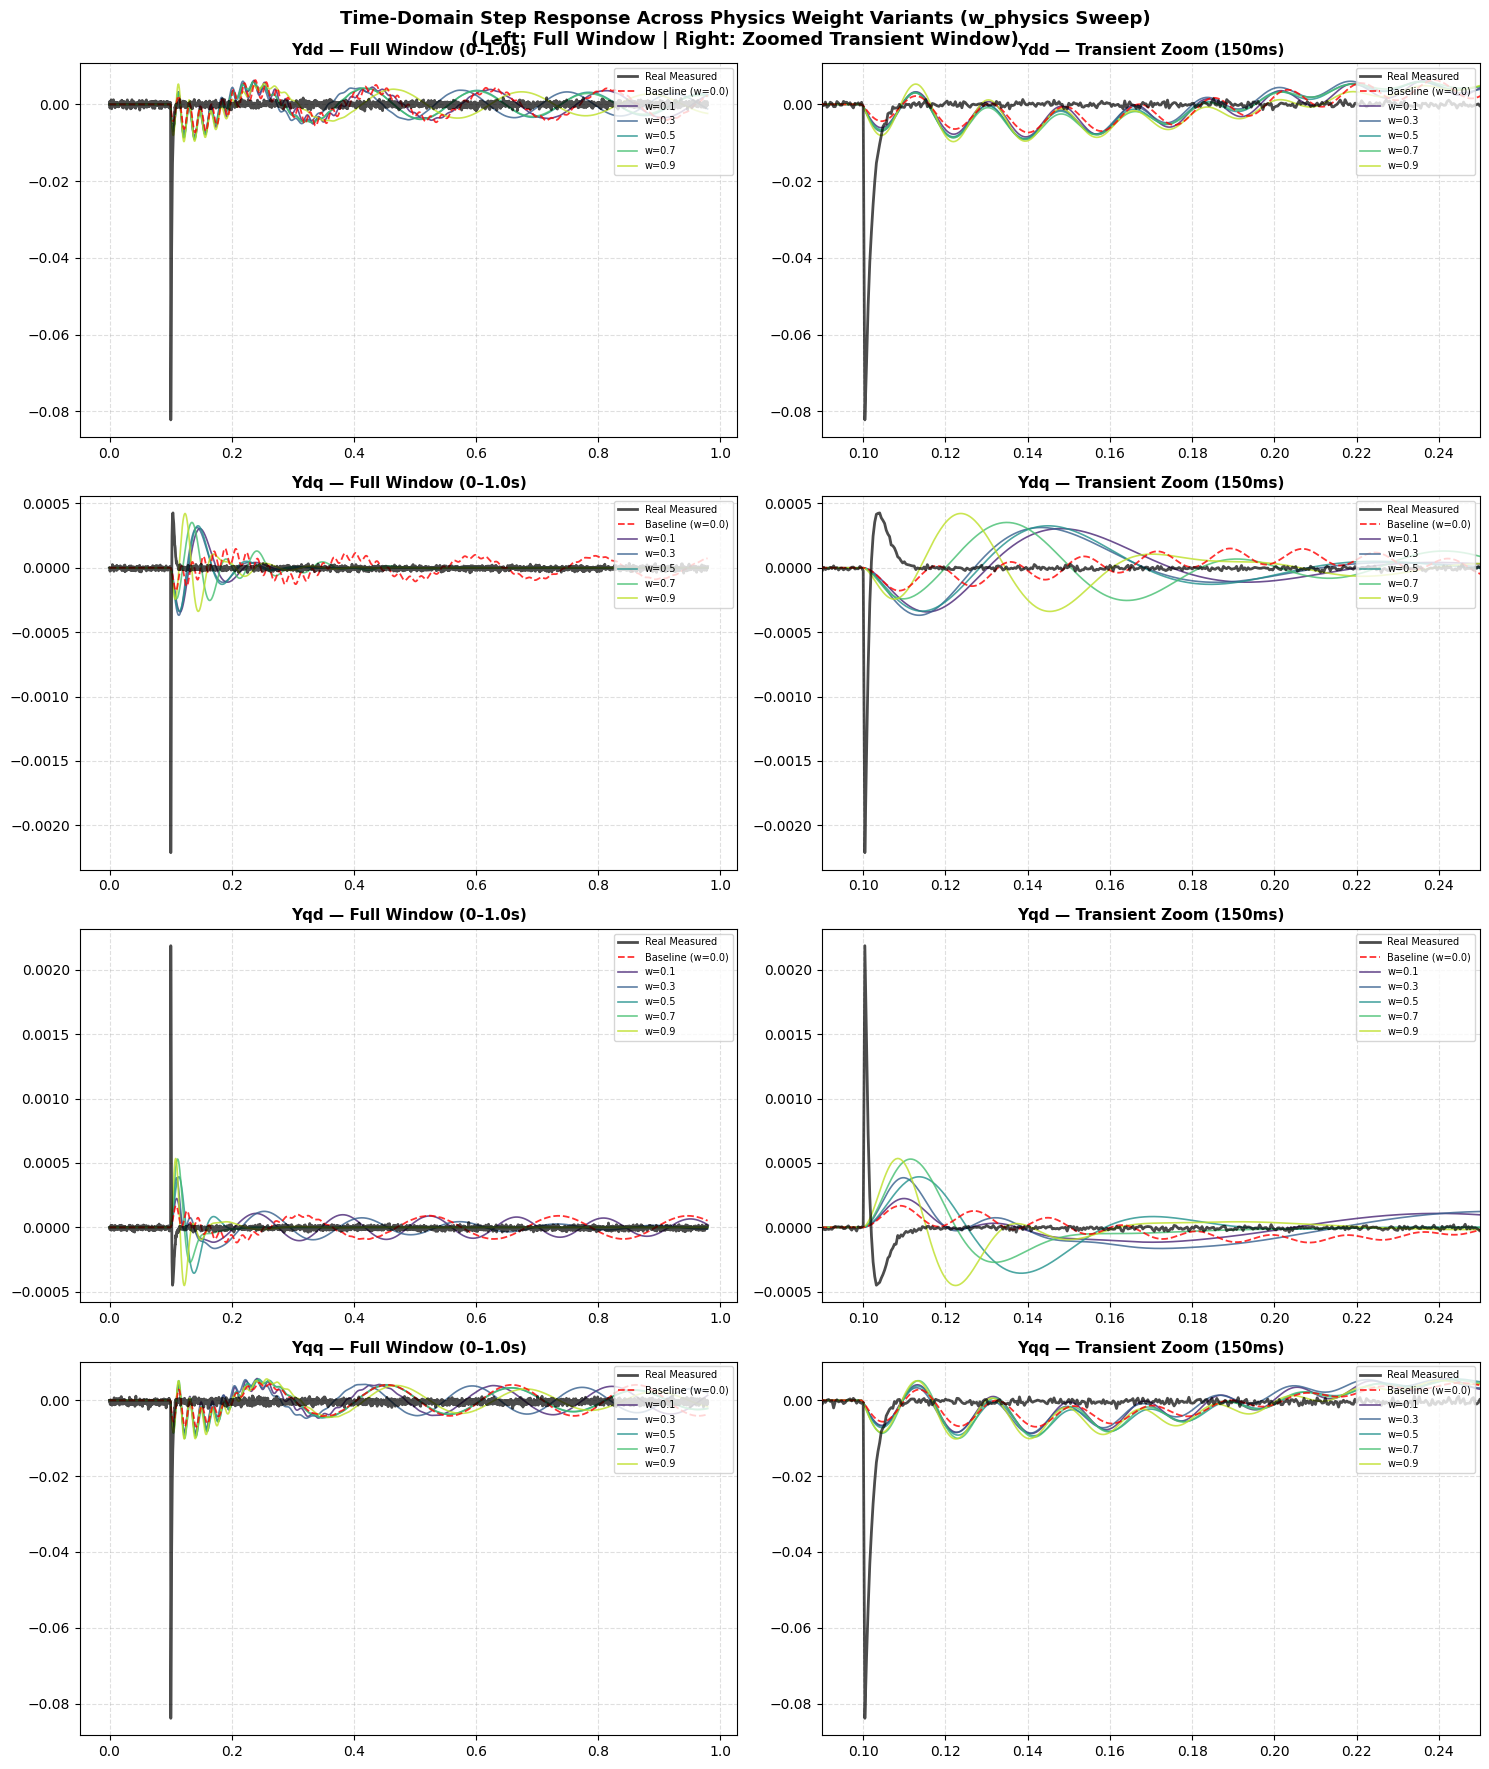


PHYSICS LOSS WEIGHT SWEEP — TIME-DOMAIN RMSE SUMMARY TABLE
Component            Model  w_physics  Full_RMSE  Transient_RMSE
      Ydd Baseline (w=0.0)        0.0   0.003882        0.007608
      Ydd     PINN (w=0.1)        0.1   0.003840        0.007693
      Ydd     PINN (w=0.3)        0.3   0.003811        0.007812
      Ydd     PINN (w=0.5)        0.5   0.003821        0.007812
      Ydd     PINN (w=0.7)        0.7   0.003815        0.007910
      Ydd     PINN (w=0.9)        0.9   0.003792        0.007812
      Ydq Baseline (w=0.0)        0.0   0.000091        0.000184
      Ydq     PINN (w=0.1)        0.1   0.000091        0.000231
      Ydq     PINN (w=0.3)        0.3   0.000092        0.000233
      Ydq     PINN (w=0.5)        0.5   0.000091        0.000232
      Ydq     PINN (w=0.7)        0.7   0.000092        0.000230
      Ydq     PINN (w=0.9)        0.9   0.000092        0.000234
      Yqd Baseline (w=0.0)        0.0   0.000090        0.000178
      Yqd     PINN (w=0.1)    

In [ ]:

import os
import glob
import numpy as np
import pandas as pd
import scipy.signal as spsig
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# --- Configuration ---
FS = 2500.0
T_WINDOW = 0.98
T_STEP_ONSET = 0.1
TRANSIENT_DURATION_S = 0.15
WEIGHT_SWEEP = [0.1, 0.3, 0.5, 0.7, 0.9]
COMPONENTS = {"Ydd": (0, 0), "Ydq": (0, 1), "Yqd": (1, 0), "Yqq": (1, 1)}
COMPONENT_CHANNEL = {"Ydd": 0, "Ydq": 2, "Yqd": 1, "Yqq": 3}
N_PAIRS = 3
NUM_LEN = 7

t = np.arange(0, T_WINDOW, 1.0 / FS)
onset_idx = int(round(T_STEP_ONSET * FS))
transient_end_idx = onset_idx + int(round(TRANSIENT_DURATION_S * FS))

# --- Missing Helper Functions & Classes Added ---
class ComponentModel(nn.Module):
    def __init__(self, in_features, hidden=256, depth=4, dropout=0.15):
        super().__init__()
        layers = [nn.Linear(in_features, hidden), nn.LayerNorm(hidden), nn.ReLU(), nn.Dropout(dropout)]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.LayerNorm(hidden), nn.ReLU(), nn.Dropout(dropout)]
        self.trunk = nn.Sequential(*layers)
        self.num_head = nn.Linear(hidden, NUM_LEN)
        self.pole_head = nn.Linear(hidden, N_PAIRS * 2)
    def forward(self, x):
        h = self.trunk(x)
        return self.num_head(h), self.pole_head(h)

def poles_to_denominator_np(pole_params):
    poly = np.array([1.0])
    for i in range(N_PAIRS):
        d_raw, omega = pole_params[2 * i], pole_params[2 * i + 1]
        sigma = np.log1p(np.exp(d_raw)) if d_raw < 30 else d_raw
        poly = np.convolve(poly, np.array([1.0, 2 * sigma, sigma ** 2 + omega ** 2]))
    return poly.ravel()

def preprocess_csv(csv_path):
    df = pd.read_csv(csv_path)
    return np.stack([df[t].values.astype(np.float32) - df[t].values.astype(np.float32)[0]
                     for t in ["id_ev1", "iq_ev1", "id_ev2", "iq_ev2"]])

def infer_component_tf_prefix(comp_name, x_window, prefix):
    norm = np.load(f"norm_tfv2_{comp_name}.npz")
    X_mean, X_std = norm["X_mean"], norm["X_std"]
    num_mean, num_std = norm["num_mean"], norm["num_std"]
    C, T = int(norm["C"]), int(norm["T"])

    x = x_window[:, :T].reshape(1, C * T)
    x_s = (x - X_mean) / X_std
    model = ComponentModel(in_features=C * T)

    # Load model
    model_path = f"best_model_{prefix}_{comp_name}.pt"
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model {model_path} not found. Ensure Cell 9 (training) completed.")

    model.load_state_dict(torch.load(model_path, map_location="cpu"))
    model.eval()

    with torch.no_grad():
        num_s, pp = model(torch.tensor(x_s, dtype=torch.float32))
    num = (num_s.numpy()[0] * num_std + num_mean).ravel()
    den = poles_to_denominator_np(pp.numpy()[0]).ravel()
    return num, den

def simulate_step(num, den, t, onset_idx, step_size=1.0):
    system = spsig.TransferFunction(num, den)
    u = np.zeros_like(t)
    u[onset_idx:] = step_size
    _, y, _ = spsig.lsim(system, U=u, T=t)
    return y

# --- Execution ---

# Locate test CSV
csv_matches = glob.glob("**/VSC_I_Id_50_SNR_15.csv", recursive=True)
assert csv_matches, "Could not find VSC_I_Id_50_SNR_15.csv. Check data folders."
test_csv = csv_matches[0]
x_window = preprocess_csv(test_csv)

fig, axes = plt.subplots(4, 2, figsize=(15, 18), facecolor="white")
fig.suptitle("Time-Domain Step Response Across Physics Weight Variants (w_physics Sweep)\n"
             "(Left: Full Window | Right: Zoomed Transient Window)", fontsize=13, fontweight="bold")

colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(WEIGHT_SWEEP)))
summary_records = []

for row, comp_name in enumerate(COMPONENTS):
    ch_idx = COMPONENT_CHANNEL[comp_name]
    y_real = x_window[ch_idx, :]

    # 1. Baseline (w_physics = 0.0)
    num_ann, den_ann = infer_component_tf_prefix(comp_name, x_window, "tfv2")
    y_ann = simulate_step(num_ann, den_ann, t, onset_idx)
    scale_ann = (np.std(y_real[onset_idx:]) + 1e-6) / (np.std(y_ann[onset_idx:]) + 1e-6)
    y_ann_scaled = y_ann * scale_ann

    rmse_full_ann = np.sqrt(np.mean((y_ann_scaled - y_real)**2))
    rmse_trans_ann = np.sqrt(np.mean((y_ann_scaled[onset_idx:transient_end_idx] - y_real[onset_idx:transient_end_idx])**2))

    summary_records.append({
        "Component": comp_name, "Model": "Baseline (w=0.0)",
        "w_physics": 0.0, "Full_RMSE": rmse_full_ann, "Transient_RMSE": rmse_trans_ann
    })

    ax_full, ax_zoom = axes[row, 0], axes[row, 1]
    for ax in (ax_full, ax_zoom):
        ax.plot(t, y_real, "k-", lw=2.0, alpha=0.7, label="Real Measured", zorder=5)
        ax.plot(t, y_ann_scaled, "r--", lw=1.3, alpha=0.8, label="Baseline (w=0.0)", zorder=4)

    # 2. Sweep Variants (w_physics in [0.1, 0.3, 0.5, 0.7, 0.9])
    for idx, w in enumerate(WEIGHT_SWEEP):
        prefix = f"pinn_w{int(w * 100)}"
        num_p, den_p = infer_component_tf_prefix(comp_name, x_window, prefix)
        y_p = simulate_step(num_p, den_p, t, onset_idx)
        scale_p = (np.std(y_real[onset_idx:]) + 1e-6) / (np.std(y_p[onset_idx:]) + 1e-6)
        y_p_scaled = y_p * scale_p

        rmse_full = np.sqrt(np.mean((y_p_scaled - y_real)**2))
        rmse_trans = np.sqrt(np.mean((y_p_scaled[onset_idx:transient_end_idx] - y_real[onset_idx:transient_end_idx])**2))

        summary_records.append({
            "Component": comp_name, "Model": f"PINN (w={w})",
            "w_physics": w, "Full_RMSE": rmse_full, "Transient_RMSE": rmse_trans
        })

        lbl = f"w={w}"
        ax_full.plot(t, y_p_scaled, color=colors[idx], lw=1.2, alpha=0.8, label=lbl)
        ax_zoom.plot(t, y_p_scaled, color=colors[idx], lw=1.2, alpha=0.8, label=lbl)

    ax_full.set_title(f"{comp_name} — Full Window (0–1.0s)", fontsize=11, fontweight="bold")
    ax_zoom.set_title(f"{comp_name} — Transient Zoom ({TRANSIENT_DURATION_S*1000:.0f}ms)", fontsize=11, fontweight="bold")
    ax_zoom.set_xlim(t[onset_idx] - 0.01, t[transient_end_idx])

    for ax in (ax_full, ax_zoom):
        ax.grid(True, ls="--", alpha=0.4)
        ax.legend(fontsize=7, loc="upper right")

plt.tight_layout()
plt.savefig("time_response_weight_sweep_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# Print Table
df_res = pd.DataFrame(summary_records)
print("\n" + "=" * 75)
print("PHYSICS LOSS WEIGHT SWEEP — TIME-DOMAIN RMSE SUMMARY TABLE")
print("=" * 75)
print(df_res.to_string(index=False))
print("=" * 75)

print("\n--- Optimal Physics Weight per Component (Lowest Transient RMSE) ---")
for comp in COMPONENTS:
    sub = df_res[df_res["Component"] == comp]
    best_row = sub.loc[sub["Transient_RMSE"].idxmin()]
    print(f"  {comp:4s} -> Best Weight: w_physics = {best_row['w_physics']} | Transient RMSE: {best_row['Transient_RMSE']:.6f}")

# 📉  Data Scarcity Benchmark: 3,000 vs. 150 Systems


In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import scipy.io as sio
import scipy.signal as sig
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

COMPONENTS = {"Ydd": (0, 0), "Ydq": (0, 1), "Yqd": (1, 0), "Yqq": (1, 1)}
QUALITY_TAG = "_worse"

scarce_manifest = glob.glob("**/training_data_out_worse_quality/**/manifest.csv", recursive=True)
if scarce_manifest:
    SCARCE_DIR = os.path.dirname(scarce_manifest[0])
    print(f"[Cell 10] Building Scarce Datasets from {SCARCE_DIR}...")
    manifest_sc = pd.read_csv(scarce_manifest[0])
    datasets_sc = {name: {"X": [], "num": [], "den": []} for name in COMPONENTS}

    for _, row in manifest_sc.iterrows():
        sys_id = int(row["sys_id"]) if "sys_id" in row else int(row.iloc[0])
        ytrue_path = os.path.join(SCARCE_DIR, str(row["ytrue_file"]))
        if not os.path.exists(ytrue_path):
            continue
        d = sio.loadmat(ytrue_path)

        Lf, Rf   = float(d["Lf"].item()),   float(d["Rf"].item())
        Kp_i, Ki_i     = float(d["Kp_i"].item()), float(d["Ki_i"].item())
        Kp_pll, Ki_pll = float(d["Kp_pll"].item()), float(d["Ki_pll"].item())
        Id_eq, Iq_eq   = float(d["Id_eq"].item()), float(d["Iq_eq"].item())

        A, B, C, D = build_A_B_C_D(Lf, Rf, Kp_i, Ki_i, Kp_pll, Ki_pll, Id_eq, Iq_eq)

        for snr in [30, 28, 26, "Inf"]:
            csv_name = f"sys_{sys_id:05d}_SNR_Inf.csv" if snr == "Inf" else f"sys_{sys_id:05d}_SNR_{snr}.csv"
            csv_path = os.path.join(SCARCE_DIR, csv_name)
            if not os.path.exists(csv_path):
                continue
            df = pd.read_csv(csv_path)
            x = df[["id_ev1", "iq_ev1", "id_ev2", "iq_ev2"]].values.T.astype(np.float32)

            for comp_name, (i, j) in COMPONENTS.items():
                num, den = sig.ss2tf(A, B, C, D, input=j)
                scale = den[0]
                if abs(scale) < 1e-8:
                    continue
                den_n, num_n = den / scale, num[i] / scale
                num_pad = np.zeros(NUM_LEN)
                num_pad[-len(num_n):] = num_n

                datasets_sc[comp_name]["X"].append(x)
                datasets_sc[comp_name]["num"].append(num_pad.astype(np.float32))
                datasets_sc[comp_name]["den"].append(den_n[1:].astype(np.float32))

    for comp_name in COMPONENTS:
        X_arr = np.array(datasets_sc[comp_name]["X"])
        num_arr = np.array(datasets_sc[comp_name]["num"])
        den_arr = np.array(datasets_sc[comp_name]["den"])
        np.savez(f"dataset_tf{QUALITY_TAG}_{comp_name}.npz", X=X_arr, num=num_arr, den=den_arr)

    print("  [Saved] Scarce datasets (dataset_tf_worse_*.npz).")
else:
    print("[Cell 10] Scarce dataset directory not found. Skipping generation.")

[Cell 10] Building Scarce Datasets from training_data_out_worse_quality/training_data_out_worse_quality...
  [Saved] Scarce datasets (dataset_tf_worse_*.npz).



--- Training Models on Scarce Dataset (150 Systems) ---
  [Saved] best_model_tfv2_worse_Ydd.pt
  [Saved] best_model_pinn_worse_Ydd.pt
  [Saved] best_model_tfv2_worse_Ydq.pt
  [Saved] best_model_pinn_worse_Ydq.pt
  [Saved] best_model_tfv2_worse_Yqd.pt
  [Saved] best_model_pinn_worse_Yqd.pt
  [Saved] best_model_tfv2_worse_Yqq.pt
  [Saved] best_model_pinn_worse_Yqq.pt


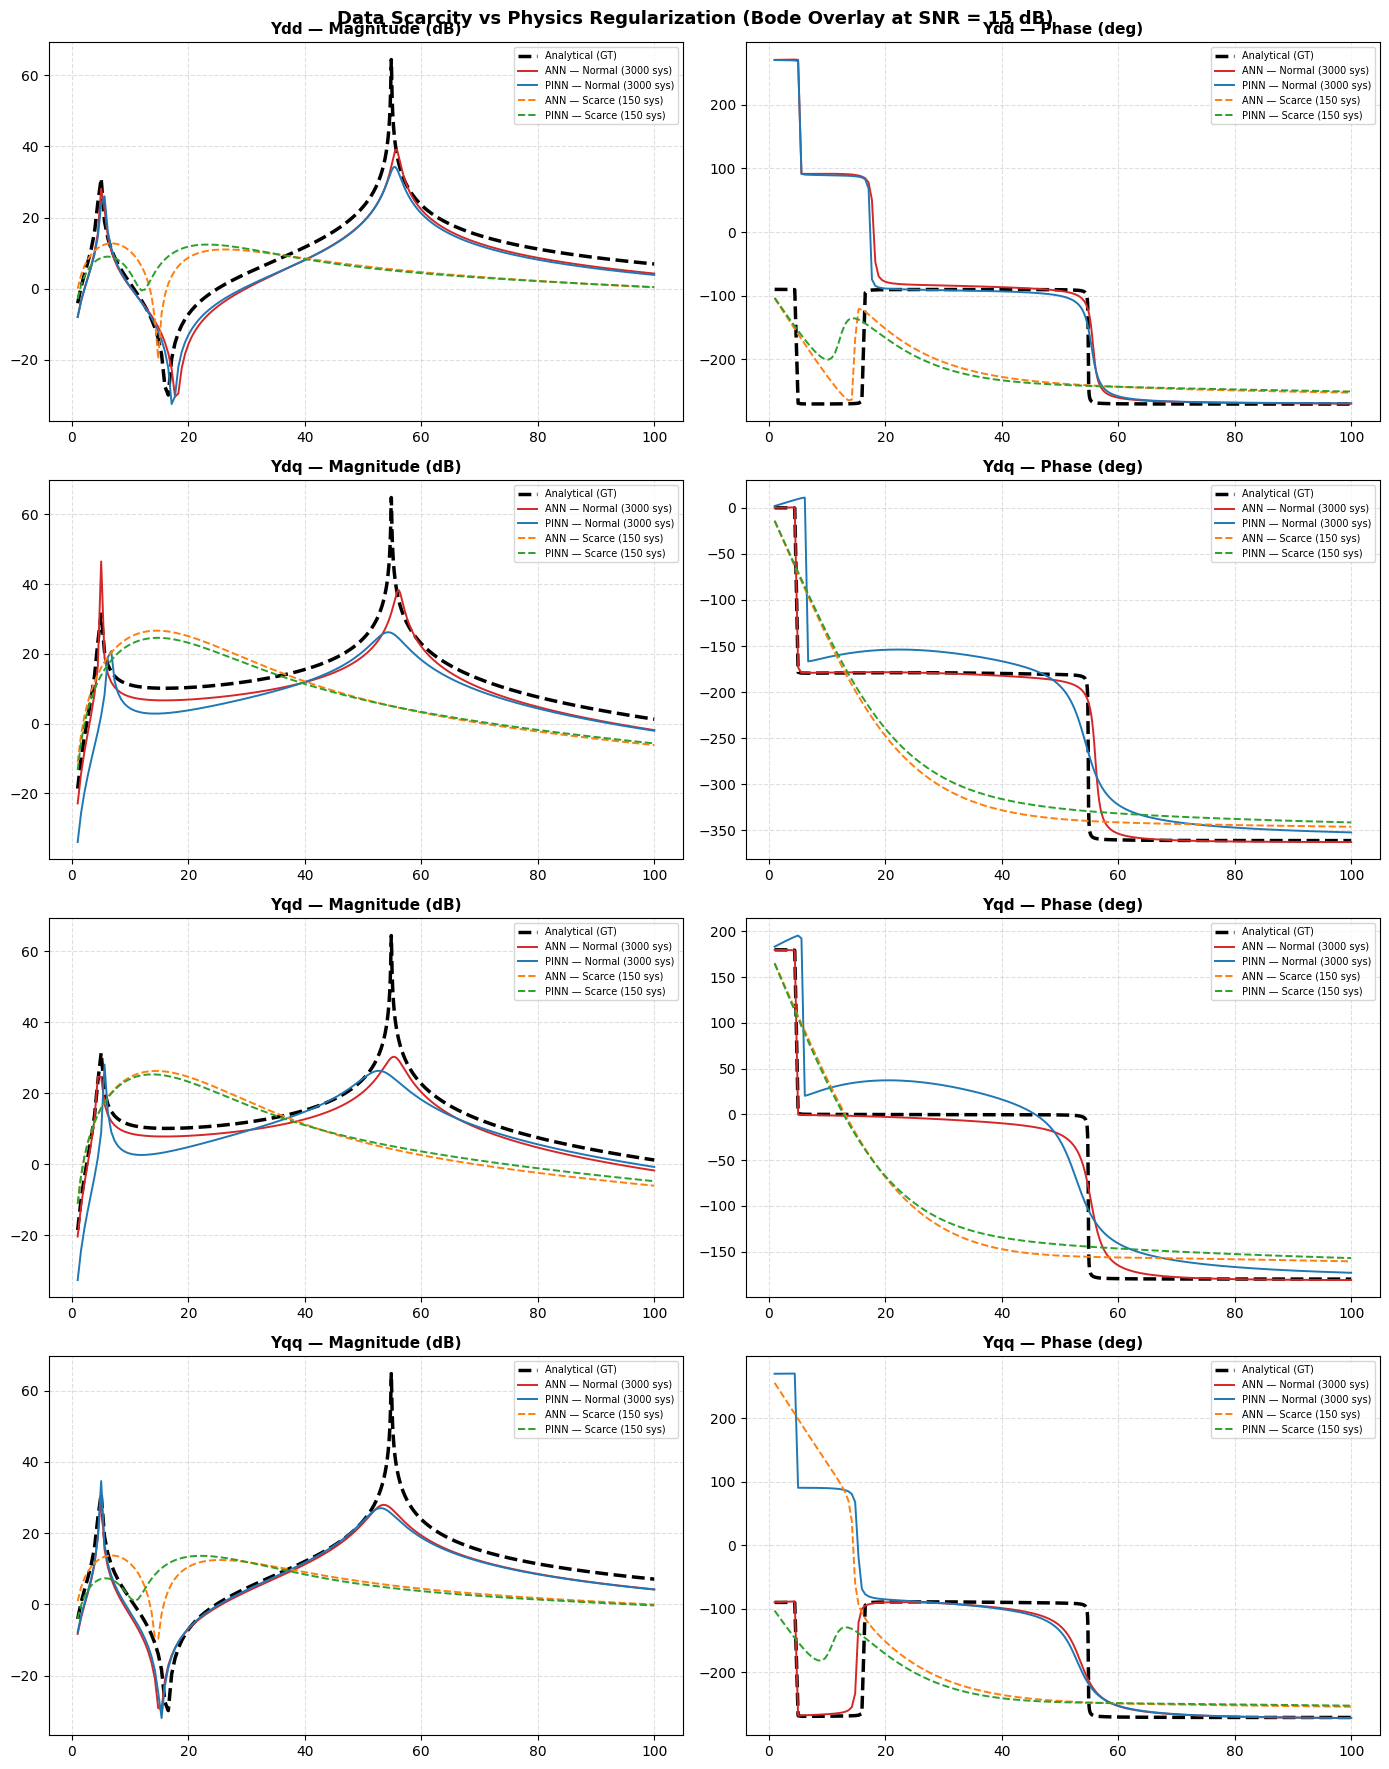

In [ ]:

import os
import glob
import numpy as np
import pandas as pd
import scipy.io as sio
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

W0 = 2.0 * np.pi * 50.0
COMPONENTS = {"Ydd": (0, 0), "Ydq": (0, 1), "Yqd": (1, 0), "Yqq": (1, 1)}
QUALITY_TAG = "_worse"
N_PAIRS = 3
NUM_LEN = 7

# ==============================================================================
# MISSING HELPER FUNCTIONS & CLASSES ADDED
# ==============================================================================
class ComponentModel(nn.Module):
    def __init__(self, in_features, hidden=256, depth=4, dropout=0.15):
        super().__init__()
        layers = [nn.Linear(in_features, hidden), nn.LayerNorm(hidden), nn.ReLU(), nn.Dropout(dropout)]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.LayerNorm(hidden), nn.ReLU(), nn.Dropout(dropout)]
        self.trunk = nn.Sequential(*layers)
        self.num_head = nn.Linear(hidden, NUM_LEN)
        self.pole_head = nn.Linear(hidden, N_PAIRS * 2)

    def forward(self, x):
        h = self.trunk(x)
        return self.num_head(h), self.pole_head(h)

def poles_to_denominator(pole_params):
    batch = pole_params.shape[0]
    quads = []
    for i in range(N_PAIRS):
        damping_raw = pole_params[:, 2*i]
        omega       = pole_params[:, 2*i + 1]
        sigma = torch.nn.functional.softplus(damping_raw)
        c0 = torch.ones(batch, device=pole_params.device)
        c1 = 2 * sigma
        c2 = sigma**2 + omega**2
        quads.append(torch.stack([c0, c1, c2], dim=1))
    poly = quads[0]
    for q in quads[1:]:
        L = poly.shape[1]
        out = torch.zeros(batch, L + 2, device=poly.device)
        for i in range(L):
            for j in range(3):
                out[:, i+j] += poly[:, i] * q[:, j]
        poly = out
    return poly

def poles_to_denominator_np(pole_params):
    poly = np.array([1.0])
    for i in range(N_PAIRS):
        d_raw, omega = pole_params[2 * i], pole_params[2 * i + 1]
        sigma = np.log1p(np.exp(d_raw)) if d_raw < 30 else d_raw
        poly = np.convolve(poly, np.array([1.0, 2 * sigma, sigma ** 2 + omega ** 2]))
    return poly.ravel()

def preprocess_csv(csv_path):
    df = pd.read_csv(csv_path)
    return np.stack([df[t].values.astype(np.float32) - df[t].values.astype(np.float32)[0]
                     for t in ["id_ev1", "iq_ev1", "id_ev2", "iq_ev2"]])

def get_clamped_poles(pole_params):
    SIGMA_MAX = 15000.0; OMEGA_MAX = 15000.0; MIN_POLE_SEPARATION = 1.0
    batch = pole_params.shape[0]
    sigma_list, omega_list = [], []
    for i in range(N_PAIRS):
        sigma = torch.clamp(torch.nn.functional.softplus(pole_params[:, 2 * i]), max=SIGMA_MAX)
        omega = torch.clamp(pole_params[:, 2 * i + 1], min=-OMEGA_MAX, max=OMEGA_MAX)
        sigma_list.append(sigma); omega_list.append(omega)
    sigma_all = torch.stack(sigma_list, dim=1)
    omega_all = torch.stack(omega_list, dim=1)
    abs_omega = omega_all.abs()
    sorted_idx = torch.argsort(abs_omega, dim=1)
    sorted_omega = torch.gather(abs_omega, 1, sorted_idx)
    for i in range(1, N_PAIRS):
        needs_push = (sorted_omega[:, i] - sorted_omega[:, i - 1]) < MIN_POLE_SEPARATION
        sorted_omega[:, i] = torch.where(needs_push, sorted_omega[:, i - 1] + MIN_POLE_SEPARATION, sorted_omega[:, i])
    fixed_abs_omega = torch.zeros_like(omega_all)
    fixed_abs_omega.scatter_(1, sorted_idx, sorted_omega)
    omega_all = torch.sign(omega_all + 1e-12) * fixed_abs_omega
    return sigma_all, omega_all

def tf_to_modal_ss_batch(num, den, sigma_all, omega_all):
    batch, dev = num.shape[0], num.device
    D_quads = [torch.stack([torch.ones(batch, device=dev), 2 * sigma_all[:, i], sigma_all[:, i]**2 + omega_all[:, i]**2], dim=1) for i in range(3)]
    def conv2(p, q):
        out = torch.zeros(batch, 5, device=dev)
        for i in range(3):
            for j in range(3):
                out[:, i + j] += p[:, i] * q[:, j]
        return out
    Dbar = [conv2(D_quads[(i + 1) % 3], D_quads[(i + 2) % 3]) for i in range(3)]
    D0 = num[:, 0:1]
    Nr = num[:, 1:] - D0 * den[:, 1:]
    M = torch.zeros(batch, 6, 6, device=dev)
    for i in range(3):
        M[:, 0:5, 2 * i] = Dbar[i]; M[:, 1:6, 2 * i + 1] = Dbar[i]
    M = M + 1e-8 * torch.eye(6, device=dev).unsqueeze(0)
    coeffs = torch.linalg.lstsq(M, Nr.unsqueeze(-1), driver='gelsd').solution.squeeze(-1)
    A = torch.zeros(batch, 6, 6, device=dev)
    B = torch.zeros(batch, 6, 1, device=dev)
    C = torch.zeros(batch, 1, 6, device=dev)
    for i in range(3):
        r = 2 * i; s2 = sigma_all[:, i]**2 + omega_all[:, i]**2
        A[:, r, r + 1] = 1.0; A[:, r + 1, r] = -s2; A[:, r + 1, r + 1] = -2 * sigma_all[:, i]
        B[:, r + 1, 0] = 1.0; C[:, 0, r] = coeffs[:, 2 * i + 1]; C[:, 0, r + 1] = coeffs[:, 2 * i]
    return A, B, C, D0.unsqueeze(-1)

def simulate_step_response(A, B, C, D, dt, n_steps, step_size, onset_step):
    A64, B64, C64, D64 = A.double(), B.double(), C.double(), D.double()
    batch, n, _ = A64.shape
    M = torch.zeros(batch, n + 1, n + 1, dtype=torch.float64, device=A64.device)
    M[:, :n, :n] = A64 * dt; M[:, :n, n:] = B64 * dt
    Md = torch.matrix_exp(M)
    Ad, Bd = Md[:, :n, :n], Md[:, :n, n:]
    x = torch.zeros(batch, n, 1, dtype=torch.float64, device=A64.device)
    ys = []
    for k in range(n_steps):
        u = step_size if k >= onset_step else 0.0
        y = torch.bmm(C64, x) + D64 * u
        ys.append(y.squeeze(-1).squeeze(-1))
        x = torch.bmm(Ad, x) + Bd * u
    return torch.stack(ys, dim=1).to(A.dtype)

# ==============================================================================
# 1. Train Base ANN on Scarce Data
# ==============================================================================
def train_scarce_ann(comp_name, epochs=100, batch_size=64, lr=1e-3):
    data = np.load(f"dataset_tf{QUALITY_TAG}_{comp_name}.npz")
    X = data["X"].astype(np.float32)
    num = data["num"].astype(np.float32)
    den_tail = data["den"].astype(np.float32)
    den = np.concatenate([np.ones((len(den_tail), 1), dtype=np.float32), den_tail], axis=1)

    N, C, T = X.shape
    X_flat = X.reshape(N, C * T)

    X_mean, X_std = X_flat.mean(0, keepdims=True), X_flat.std(0, keepdims=True) + 1e-8
    num_mean, num_std = num.mean(0, keepdims=True), num.std(0, keepdims=True) + 1e-8
    den_std = np.maximum(den.std(0, keepdims=True), 1e-6)
    den_mean = den.mean(0, keepdims=True)

    np.savez(f"norm_tfv2{QUALITY_TAG}_{comp_name}.npz", X_mean=X_mean, X_std=X_std,
             num_mean=num_mean, num_std=num_std, den_std=den_std, C=C, T=T)

    X_s = (X_flat - X_mean) / X_std
    num_s = (num - num_mean) / num_std

    ds = TensorDataset(torch.tensor(X_s), torch.tensor(num_s), torch.tensor(den))
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True)

    model = ComponentModel(in_features=C * T).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mse = nn.MSELoss()
    den_std_t = torch.tensor(den_std, dtype=torch.float32).to(device)

    for epoch in range(epochs):
        model.train()
        for xb, numb_s, denb in loader:
            xb, numb_s, denb = xb.to(device), numb_s.to(device), denb.to(device)
            optimizer.zero_grad()
            np_s, pp = model(xb)
            dp = poles_to_denominator(pp)
            loss = mse(np_s, numb_s) + mse(dp / den_std_t, denb / den_std_t)
            loss.backward()
            optimizer.step()

    torch.save(model.state_dict(), f"best_model_tfv2{QUALITY_TAG}_{comp_name}.pt")
    print(f"  [Saved] best_model_tfv2{QUALITY_TAG}_{comp_name}.pt")

# ==============================================================================
# 2. Train PINN on Scarce Data
# ==============================================================================
def finetune_scarce_pinn(comp_name, epochs=30, batch_size=64, lr=3e-4, lambda_pinn=0.08):
    data = np.load(f"dataset_tf{QUALITY_TAG}_{comp_name}.npz")
    X = data["X"].astype(np.float32)
    num_true = data["num"].astype(np.float32)
    den_tail_true = data["den"].astype(np.float32)
    den_true = np.concatenate([np.ones((len(den_tail_true), 1), dtype=np.float32), den_tail_true], axis=1)

    norm = np.load(f"norm_tfv2{QUALITY_TAG}_{comp_name}.npz")
    X_mean, X_std = norm["X_mean"], norm["X_std"]
    num_mean, num_std = norm["num_mean"], norm["num_std"]
    den_std = norm["den_std"]
    N, C, T = X.shape
    X_s = (X.reshape(N, C * T) - X_mean) / X_std
    num_s = (num_true - num_mean) / num_std

    ch_idx = {"Ydd": 0, "Ydq": 2, "Yqd": 1, "Yqq": 3}[comp_name]
    y_meas_dec = X[:, ch_idx, ::10]
    n_steps_dec = y_meas_dec.shape[1]
    dt_dec = 10 / 2500.0
    onset_dec = int(round(0.1 / dt_dec))

    ds = TensorDataset(torch.tensor(X_s), torch.tensor(num_s), torch.tensor(den_true), torch.tensor(y_meas_dec))
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True)

    model = ComponentModel(in_features=C * T).to(device)
    model.load_state_dict(torch.load(f"best_model_tfv2{QUALITY_TAG}_{comp_name}.pt", map_location=device))

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mse = nn.MSELoss()
    den_std_t = torch.tensor(den_std, dtype=torch.float32).to(device)
    num_std_t = torch.tensor(num_std, dtype=torch.float32).to(device)
    num_mean_t = torch.tensor(num_mean, dtype=torch.float32).to(device)

    for epoch in range(epochs):
        model.train()
        for xb, numb_s, denb, yb_meas in loader:
            xb, numb_s, denb, yb_meas = xb.to(device), numb_s.to(device), denb.to(device), yb_meas.to(device)
            optimizer.zero_grad()
            np_s, pp = model(xb)
            sig_a, omg_a = get_clamped_poles(pp)
            dp = poles_to_denominator(pp)
            num_p = np_s * num_std_t + num_mean_t
            A, B, Cm, D = tf_to_modal_ss_batch(num_p, dp, sig_a, omg_a)
            ysim = simulate_step_response(A, B, Cm, D, dt_dec, n_steps_dec, 1.0, onset_dec)
            scale = yb_meas.std(dim=1, keepdim=True) + 1e-6
            loss_pinn = torch.clamp(mse(ysim / scale, yb_meas / scale), max=1e4)
            loss = mse(np_s, numb_s) + mse(dp / den_std_t, denb / den_std_t) + lambda_pinn * loss_pinn
            if torch.isfinite(loss):
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                optimizer.step()

    torch.save(model.state_dict(), f"best_model_pinn{QUALITY_TAG}_{comp_name}.pt")
    print(f"  [Saved] best_model_pinn{QUALITY_TAG}_{comp_name}.pt")

print("\n--- Training Models on Scarce Dataset (150 Systems) ---")
for comp in COMPONENTS:
    train_scarce_ann(comp)
    finetune_scarce_pinn(comp)

# ==============================================================================
# 3. 4-Way Bode Overlay (Evaluating & Plotting)
# ==============================================================================
gt = sio.loadmat(glob.glob("**/vsc_data_out4/**/VSC_I_admittance_groundtruth.mat", recursive=True)[0])
freqs_Hz = gt["freqs_Hz"].ravel()
Y_ref = np.transpose(gt["Y_true"], (2, 0, 1))
test_csv = glob.glob("**/VSC_I_Id_50_SNR_15.csv", recursive=True)[0]
x_window = preprocess_csv(test_csv)

SCENARIOS = [
    ("tfv2", "",       "ANN — Normal (3000 sys)",   "tab:red",    "-"),
    ("pinn", "",       "PINN — Normal (3000 sys)",  "tab:blue",   "-"),
    ("tfv2", "_worse", "ANN — Scarce (150 sys)",    "tab:orange", "--"),
    ("pinn", "_worse", "PINN — Scarce (150 sys)",   "tab:green",  "--")
]

def infer_any_tf(comp_name, x_w, stage, tag):
    norm = np.load(f"norm_tfv2{tag}_{comp_name}.npz")
    X_mean, X_std = norm["X_mean"], norm["X_std"]
    num_mean, num_std = norm["num_mean"], norm["num_std"]
    C, T = int(norm["C"]), int(norm["T"])
    x = x_w[:, :T].reshape(1, C * T)
    x_s = (x - X_mean) / X_std
    model = ComponentModel(in_features=C * T)
    model.load_state_dict(torch.load(f"best_model_{stage}{tag}_{comp_name}.pt", map_location="cpu"))
    model.eval()
    with torch.no_grad():
        num_s, pp = model(torch.tensor(x_s, dtype=torch.float32))
    num = (num_s.numpy()[0] * num_std + num_mean).ravel()
    den = poles_to_denominator_np(pp.numpy()[0]).ravel()
    return num, den

fig, axes = plt.subplots(4, 2, figsize=(14, 18), facecolor="white")
fig.suptitle("Data Scarcity vs Physics Regularization (Bode Overlay at SNR = 15 dB)", fontsize=13, fontweight="bold")

for row, (comp_name, (i, j)) in enumerate(COMPONENTS.items()):
    ax_m, ax_p = axes[row, 0], axes[row, 1]
    ref_m = 20 * np.log10(np.abs(Y_ref[:, i, j]) + 1e-12)
    ref_p = np.degrees(np.unwrap(np.angle(Y_ref[:, i, j])))

    ax_m.plot(freqs_Hz, ref_m, "k--", lw=2.5, label="Analytical (GT)")
    ax_p.plot(freqs_Hz, ref_p, "k--", lw=2.5, label="Analytical (GT)")

    for stage, tag, lbl, col, ls in SCENARIOS:
        num, den = infer_any_tf(comp_name, x_window, stage, tag)
        s = 1j * 2 * np.pi * freqs_Hz
        Y_p = np.polyval(num, s) / np.polyval(den, s)

        mag = 20 * np.log10(np.abs(Y_p) + 1e-12)
        ph  = np.degrees(np.unwrap(np.angle(Y_p)))
        shift = 360 * np.round(np.median(ref_p - ph) / 360)
        ph = ph + shift

        ax_m.plot(freqs_Hz, mag, color=col, ls=ls, lw=1.4, label=lbl)
        ax_p.plot(freqs_Hz, ph,  color=col, ls=ls, lw=1.4, label=lbl)

    ax_m.set_title(f"{comp_name} — Magnitude (dB)", fontsize=11, fontweight="bold")
    ax_p.set_title(f"{comp_name} — Phase (deg)", fontsize=11, fontweight="bold")
    for ax in (ax_m, ax_p):
        ax.grid(True, ls="--", alpha=0.4); ax.legend(fontsize=7, loc="upper right")

plt.tight_layout()
plt.savefig("bode_data_scarcity_comparison.png", dpi=300, bbox_inches='tight')
plt.show()


Component  Window       ANN — Normal (3000 sys) PINN — Normal (3000 sys) ANN — Scarce (150 sys) PINN — Scarce (150 sys)
Ydd        Full                        0.00388                0.00387                0.00384                0.00375
Ydd        Transient                   0.00761                0.00757                0.00974                0.00950
Ydq        Full                        0.00009                0.00009                0.00009                0.00009
Ydq        Transient                   0.00018                0.00019                0.00023                0.00023
Yqd        Full                        0.00009                0.00009                0.00009                0.00009
Yqd        Transient                   0.00018                0.00019                0.00023                0.00023
Yqq        Full                        0.00394                0.00395                0.00390                0.00377
Yqq        Transient                   0.00761                0.007

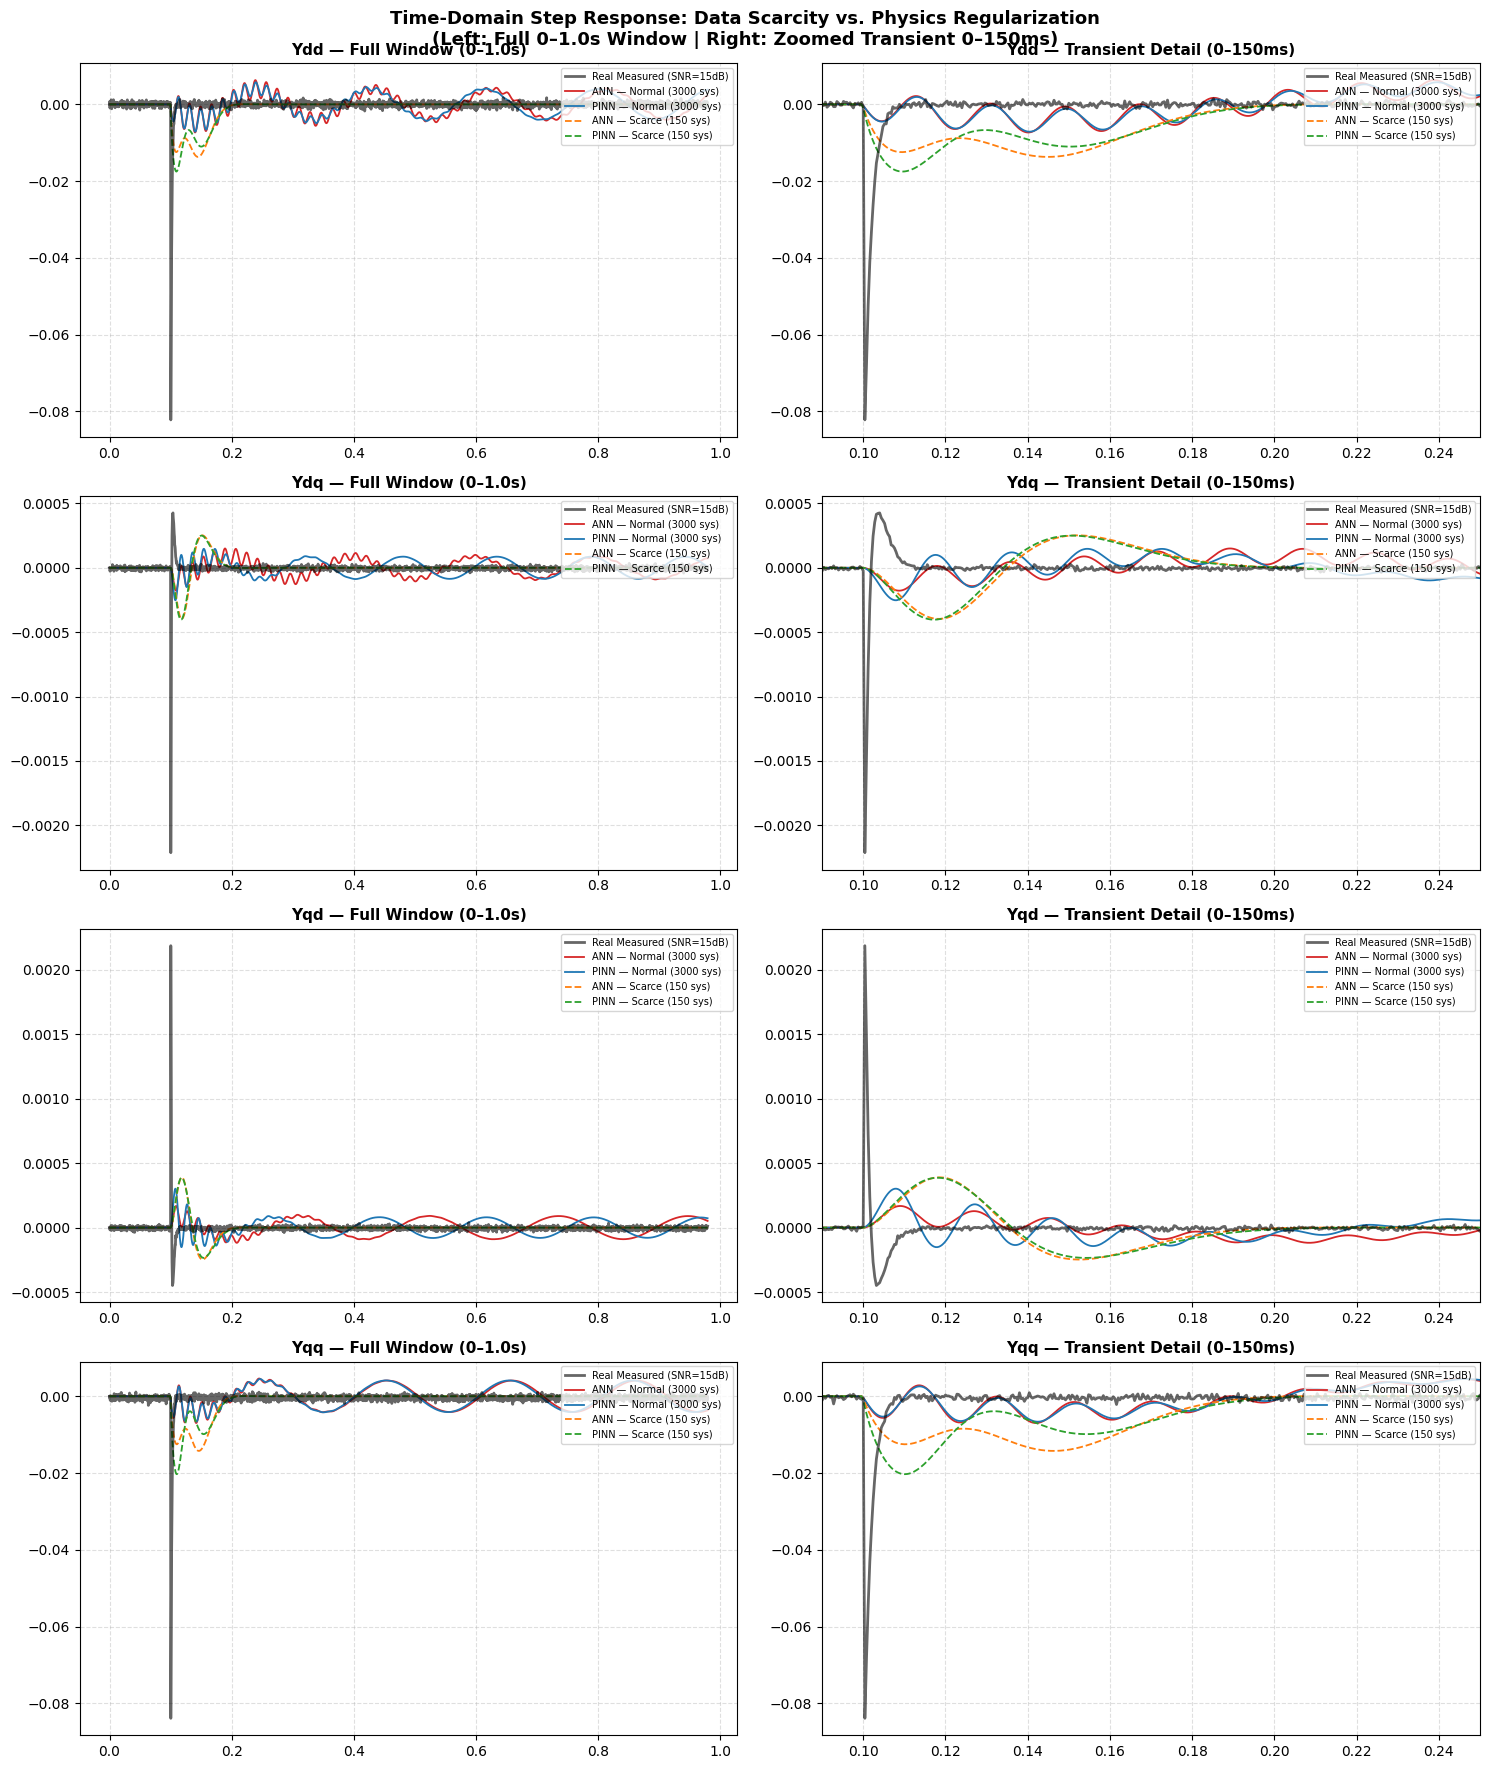


🎉 Time-domain data scarcity comparison figure exported to 'time_domain_data_scarcity_comparison.png'.


In [ ]:

import os
import glob
import numpy as np
import pandas as pd
import scipy.signal as spsig
import matplotlib.pyplot as plt
import torch
import torch.nn as nn


# Configuration and Time Base
FS = 2500.0
T_WINDOW = 0.98
T_STEP_ONSET = 0.1
TRANSIENT_DURATION_S = 0.15
N_PAIRS = 3
NUM_LEN = 7

COMPONENTS = {"Ydd": (0, 0), "Ydq": (0, 1), "Yqd": (1, 0), "Yqq": (1, 1)}
COMPONENT_CHANNEL = {"Ydd": 0, "Ydq": 2, "Yqd": 1, "Yqq": 3}

t = np.arange(0, T_WINDOW, 1.0 / FS)
onset_idx = int(round(T_STEP_ONSET * FS))
transient_end_idx = onset_idx + int(round(TRANSIENT_DURATION_S * FS))

class ComponentModel(nn.Module):
    def __init__(self, in_features, hidden=256, depth=4, dropout=0.15):
        super().__init__()
        layers = [nn.Linear(in_features, hidden), nn.LayerNorm(hidden), nn.ReLU(), nn.Dropout(dropout)]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.LayerNorm(hidden), nn.ReLU(), nn.Dropout(dropout)]
        self.trunk = nn.Sequential(*layers)
        self.num_head = nn.Linear(hidden, NUM_LEN)
        self.pole_head = nn.Linear(hidden, N_PAIRS * 2)

    def forward(self, x):
        h = self.trunk(x)
        return self.num_head(h), self.pole_head(h)

def poles_to_denominator_np(pole_params):
    poly = np.array([1.0])
    for i in range(N_PAIRS):
        d_raw, omega = pole_params[2 * i], pole_params[2 * i + 1]
        sigma = np.log1p(np.exp(d_raw)) if d_raw < 30 else d_raw
        poly = np.convolve(poly, np.array([1.0, 2 * sigma, sigma ** 2 + omega ** 2]))
    return poly.ravel()

def preprocess_csv(csv_path):
    df = pd.read_csv(csv_path)
    return np.stack([df[c].values.astype(np.float32) - df[c].values.astype(np.float32)[0]
                     for c in ["id_ev1", "iq_ev1", "id_ev2", "iq_ev2"]])

def infer_any_tf(comp_name, x_w, stage, tag):
    norm = np.load(f"norm_tfv2{tag}_{comp_name}.npz")
    X_mean, X_std = norm["X_mean"], norm["X_std"]
    num_mean, num_std = norm["num_mean"], norm["num_std"]
    C, T = int(norm["C"]), int(norm["T"])

    x = x_w[:, :T].reshape(1, C * T)
    x_s = (x - X_mean) / X_std
    model = ComponentModel(in_features=C * T)
    model.load_state_dict(torch.load(f"best_model_{stage}{tag}_{comp_name}.pt", map_location="cpu"))
    model.eval()

    with torch.no_grad():
        num_s, pp = model(torch.tensor(x_s, dtype=torch.float32))
    num = (num_s.numpy()[0] * num_std + num_mean).ravel()
    den = poles_to_denominator_np(pp.numpy()[0]).ravel()
    return num, den

def simulate_step(num, den, t, onset_idx, step_size=1.0):
    system = spsig.TransferFunction(num, den)
    u = np.zeros_like(t)
    u[onset_idx:] = step_size
    _, y, _ = spsig.lsim(system, U=u, T=t)
    return y

# Locate test CSV (VSC I at SNR = 15 dB)
test_csv = glob.glob("**/VSC_I_Id_50_SNR_15.csv", recursive=True)[0]
x_window = preprocess_csv(test_csv)

# 4-Way Comparison Scenarios
SCENARIOS = [
    ("tfv2", "",       "ANN — Normal (3000 sys)",   "tab:red",    "-"),
    ("pinn", "",       "PINN — Normal (3000 sys)",  "tab:blue",   "-"),
    ("tfv2", "_worse", "ANN — Scarce (150 sys)",    "tab:orange", "--"),
    ("pinn", "_worse", "PINN — Scarce (150 sys)",   "tab:green",  "--")
]

fig, axes = plt.subplots(4, 2, figsize=(15, 18), facecolor="white")
fig.suptitle("Time-Domain Step Response: Data Scarcity vs. Physics Regularization\n"
             "(Left: Full 0–1.0s Window | Right: Zoomed Transient 0–150ms)",
             fontsize=13, fontweight="bold")

header = f"{'Component':10s} {'Window':12s} " + " ".join(f"{lbl:>22s}" for _, _, lbl, _, _ in SCENARIOS)
print("\n" + "=" * 115)
print(header)
print("=" * 115)

for row, comp_name in enumerate(COMPONENTS):
    ch_idx = COMPONENT_CHANNEL[comp_name]
    y_real = x_window[ch_idx, :]

    ax_full, ax_zoom = axes[row, 0], axes[row, 1]
    for ax in (ax_full, ax_zoom):
        ax.plot(t, y_real, "k-", lw=2.0, alpha=0.6, label="Real Measured (SNR=15dB)", zorder=5)

    rmse_full_row, rmse_trans_row = [], []

    for stage, tag, lbl, color, ls in SCENARIOS:
        num, den = infer_any_tf(comp_name, x_window, stage, tag)
        y_pred = simulate_step(num, den, t, onset_idx)

        # Scale alignment for visual waveform comparison
        scale = (np.std(y_real[onset_idx:]) + 1e-6) / (np.std(y_pred[onset_idx:]) + 1e-6)
        y_pred_scaled = y_pred * scale

        for ax in (ax_full, ax_zoom):
            ax.plot(t, y_pred_scaled, color=color, ls=ls, lw=1.3, label=lbl)

        # Compute RMSE on both full and transient windows
        rmse_full = np.sqrt(np.mean((y_pred_scaled - y_real)**2))
        rmse_trans = np.sqrt(np.mean((y_pred_scaled[onset_idx:transient_end_idx] - y_real[onset_idx:transient_end_idx])**2))
        rmse_full_row.append(rmse_full)
        rmse_trans_row.append(rmse_trans)

    ax_full.set_title(f"{comp_name} — Full Window (0–1.0s)", fontsize=11, fontweight="bold")
    ax_zoom.set_title(f"{comp_name} — Transient Detail (0–{TRANSIENT_DURATION_S*1000:.0f}ms)", fontsize=11, fontweight="bold")
    ax_zoom.set_xlim(t[onset_idx] - 0.01, t[transient_end_idx])

    for ax in (ax_full, ax_zoom):
        ax.grid(True, ls="--", alpha=0.4)
        ax.legend(fontsize=7, loc="upper right")

    print(f"{comp_name:10s} {'Full':12s} " + " ".join(f"{v:22.5f}" for v in rmse_full_row))
    print(f"{comp_name:10s} {'Transient':12s} " + " ".join(f"{v:22.5f}" for v in rmse_trans_row))

print("=" * 115)

plt.tight_layout()
plt.savefig("time_domain_data_scarcity_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n🎉 Time-domain data scarcity comparison figure exported to 'time_domain_data_scarcity_comparison.png'.")